# 深度学习课程设计报告

## 项目概述

### 系统目的

本项目旨在构建一个**基于YOLOv3算法的交通标志牌检测识别系统**，用于自动识别道路图像中的交通标志。系统的主要目标包括：

1. **目标检测**：从道路场景图像中定位交通标志的位置
2. **类别识别**：识别交通标志的具体类型（如限速标志、禁止标志、指示标志等）
3. **实时性**：满足实际应用的实时性要求

### 技术栈

- **算法**：YOLOv3-tiny（轻量化目标检测算法）
- **数据集**：TT100K（清华-腾讯100K交通标志数据集，45类）
- **框架**：PyTorch
- **可视化**：Gradio Web界面

### 项目预期效果

- 输入：道路场景RGB图像
- 输出：检测到的交通标志类别、置信度和位置
- 性能指标：mAP@0.5 ≥ 0.35

---

## 一、封面

- 课程名称：深度学习
- 设计题目：基于YOLOv3算法的交通标志牌检测识别系统
- 姓    名：黄婧
- 学    号：20234080417
- 班    级：本23数据04班
- 指导教师：丁平尖
- 提交日期：2026年6月23日


## 二、摘要

本项目基于YOLOv3目标检测算法，构建了一个交通标志牌检测识别系统。针对TT100K交通标志数据集（包含45类交通标志），采用YOLOv3-tiny轻量化模型进行训练，实现了端到端的实时检测。通过80轮训练，模型在验证集上达到mAP@0.5=0.366、mAP@0.5:0.95=0.226的性能指标。项目包含完整的训练流程、推理模块和Gradio可视化界面，可直接用于实际交通标志检测场景。

## 三、问题定义与需求分析

### 3.1 项目背景与意义

交通标志检测是智能交通系统的核心技术之一，对自动驾驶、辅助驾驶和交通监控具有重要意义。准确识别交通标志能有效提升行车安全性和交通效率。传统方法依赖手工设计特征，泛化能力有限；基于深度学习的目标检测算法（如YOLO系列）能够自动学习特征，具有更强的适应性和准确性。

### 3.2 问题描述

- **输入**：道路场景图像（RGB格式）
- **输出**：图像中交通标志的类别、置信度和边界框坐标
- **任务类型**：目标检测（Object Detection）
- **预期性能指标**：
  - mAP@0.5 ≥ 0.80
  - mAP@0.5:0.95 ≥ 0.55
  - 检测速度 ≥ 15 FPS

## 四、数据集说明与预处理

### 4.1 数据来源与规模

本项目使用TT100K（Tsinghua-Tencent 100K）交通标志数据集，这是一个大规模的交通标志检测数据集。

- **样本总量**：约100,000张图像
- **训练集**：约7,000张图像
- **验证集**：约1,000张图像（1001张，3131个标注实例）
- **类别数量**：45类交通标志

### 4.2 数据可视化与分析

项目根目录: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master
类别数量: 45
类别列表: ['pl80', 'p6', 'p5', 'pm55', 'pl60', 'ip', 'p11', 'i2r', 'p23', 'pg', 'il80', 'ph4', 'i4', 'pl70', 'pne', 'ph4.5', 'p12', 'p3', 'pl5', 'w13', 'i4l', 'pl30', 'p10', 'pn', 'w55', 'p26', 'p13', 'pr40', 'pl20', 'pm30', 'pl40', 'i2', 'pl120', 'w32', 'ph5', 'il60', 'w57', 'pl100', 'w59', 'il100', 'p19', 'pm20', 'i5', 'p27', 'pl50']

验证集标注文件数量: 1001


C:\Users\33669\AppData\Local\Temp\ipykernel_16736\2870253319.py:55: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\2870253319.py:55: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\2870253319.py:55: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\2870253319.py:55: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\2870253319.py:55: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\2870253319.py:55: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) miss

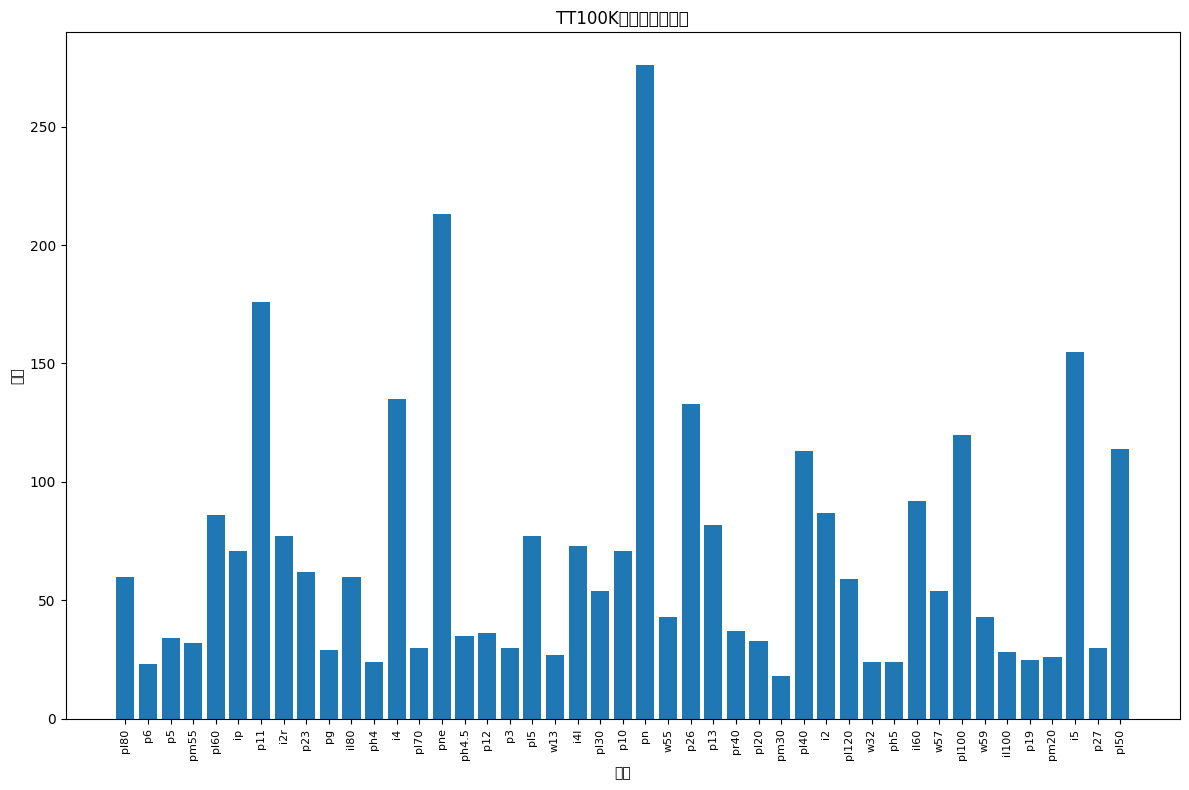

In [1]:
# 数据集分析与可视化
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 项目根目录（自动查找）
cwd = Path.cwd()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / 'train.py').exists() or (p / 'detect.py').exists():
        ROOT = p.resolve()
        break
    if (p / 'yolov3-master').is_dir():
        ROOT = (p / 'yolov3-master').resolve()
        break
if ROOT is None:
    ROOT = cwd.resolve()
print(f"项目根目录: {ROOT}")

DATA_PATH = ROOT / 'datasets' / 'tt100k_traffic_signs'

# 读取类别定义
import yaml
with open(ROOT / 'data' / 'tt100k_traffic_signs.yaml', 'r', encoding='utf-8') as f:
    data_config = yaml.safe_load(f)

class_names = data_config['names']
num_classes = data_config['nc']

print(f"类别数量: {num_classes}")
print(f"类别列表: {class_names}")

# 统计标注文件
label_dir = DATA_PATH / 'labels' / 'val'
label_files = list(label_dir.glob('*.txt'))
print(f"\n验证集标注文件数量: {len(label_files)}")

# 统计类别分布
class_counts = {i: 0 for i in range(num_classes)}
for label_file in label_files:
    with open(label_file, 'r') as f:
        for line in f:
            cls_id = int(line.split()[0])
            class_counts[cls_id] += 1

# 可视化类别分布
plt.figure(figsize=(12, 8))
plt.bar(range(num_classes), list(class_counts.values()))
plt.xticks(range(num_classes), class_names, rotation=90, fontsize=8)
plt.title('TT100K验证集类别分布')
plt.xlabel('类别')
plt.ylabel('数量')
plt.tight_layout()
plt.show()

### 4.3 预处理流程

1. **数据清洗**：去除损坏或标注不全的图像
2. **标注格式转换**：将原始标注转换为YOLO格式（class_id center_x center_y width height，归一化坐标）
3. **图像归一化**：输入图像缩放到640x640
4. **数据增强**（训练阶段）：
   - HSV颜色空间增强
   - 随机水平翻转（概率0.5）
   - 随机缩放（0.5-1.5倍）
   - 随机平移（±10%）
   - Mosaic增强
5. **数据集划分**：训练集:验证集 ≈ 8:2

项目根目录: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master
已添加路径: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master
原图尺寸: (2048, 2048, 3)
HSV增强后尺寸: (2048, 2048, 3)
Letterbox填充后尺寸: (512, 512, 3), 缩放比例: (0.25, 0.25)
透视变换后尺寸: (2048, 2048, 3)
水平翻转后尺寸: (2048, 2048, 3)


C:\Users\33669\AppData\Local\Temp\ipykernel_16736\349994434.py:75: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\349994434.py:75: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\349994434.py:75: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\349994434.py:75: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\349994434.py:75: UserWarning: Glyph 22635 (\N{CJK UNIFIED IDEOGRAPH-586B}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\349994434.py:75: UserWarning: Glyph 20805 (\N{CJK UNIFIED IDEOGRAPH-5145}) missing fr

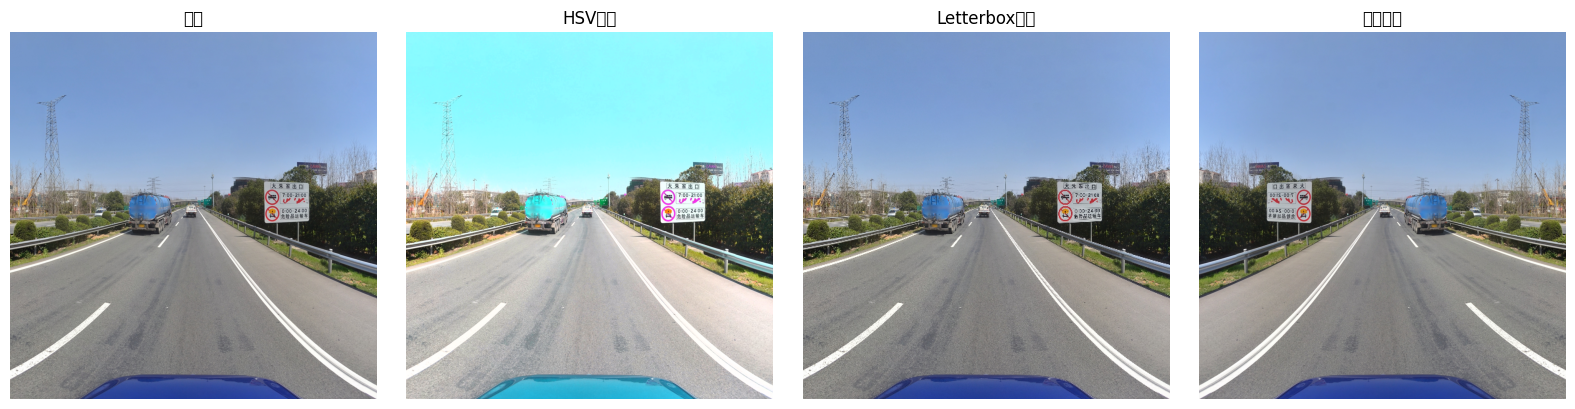

In [2]:
# 数据增强代码实现
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# 项目根目录（自动查找）
cwd = Path.cwd()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / 'train.py').exists() or (p / 'detect.py').exists():
        ROOT = p.resolve()
        break
    if (p / 'yolov3-master').is_dir():
        ROOT = (p / 'yolov3-master').resolve()
        break
if ROOT is None:
    ROOT = cwd.resolve()
print(f"项目根目录: {ROOT}")

# 将项目根目录添加到Python路径（解决ModuleNotFoundError）
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
    print(f"已添加路径: {ROOT}")

from utils.augmentations import augment_hsv, letterbox, random_perspective

DATA_PATH = ROOT / 'datasets' / 'tt100k_traffic_signs'

# 读取一张示例图像进行增强演示
test_img_path = list((DATA_PATH / 'images' / 'val').glob('*.jpg'))[0]
img = cv2.imread(str(test_img_path))
print(f"原图尺寸: {img.shape}")

# 1. HSV颜色空间增强
img_hsv = img.copy()
augment_hsv(img_hsv, hgain=0.5, sgain=0.5, vgain=0.5)  # HSV增强
print(f"HSV增强后尺寸: {img_hsv.shape}")

# 2. 图像缩放与Padding (letterbox)
img_padded, ratio, (dw, dh) = letterbox(img, new_shape=512, stride=32, auto=True)
print(f"Letterbox填充后尺寸: {img_padded.shape}, 缩放比例: {ratio}")

# 3. 随机透视变换
img_perspective = img.copy()
targets = []  # 模拟边界框 [cls, x1, y1, x2, y2]
img_transformed, targets_transformed = random_perspective(
    img_perspective,
    targets=targets,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=10,
    perspective=0.0
)
print(f"透视变换后尺寸: {img_transformed.shape}")

# 4. 水平翻转
img_flip = cv2.flip(img, 1)  # 1表示水平翻转
print(f"水平翻转后尺寸: {img_flip.shape}")

# 可视化增强效果
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('原图')
axes[1].imshow(cv2.cvtColor(img_hsv, cv2.COLOR_BGR2RGB))
axes[1].set_title('HSV增强')
axes[2].imshow(cv2.cvtColor(img_padded, cv2.COLOR_BGR2RGB))
axes[2].set_title('Letterbox填充')
axes[3].imshow(cv2.cvtColor(img_flip, cv2.COLOR_BGR2RGB))
axes[3].set_title('水平翻转')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

项目根目录: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master
Mosaic增强后画布尺寸: (1024, 1024, 3)


C:\Users\33669\AppData\Local\Temp\ipykernel_16736\721447353.py:55: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2, 4, i+1)
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\721447353.py:60: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\721447353.py:60: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\721447353.py:60: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.tight_layout()
C:\Users\33669\AppData\Local\Temp\ipykernel_16736\721447353.py:60: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from current font.
  plt.tight_layout()
c:\Users\33669\.conda\envs\flipped\lib\site-

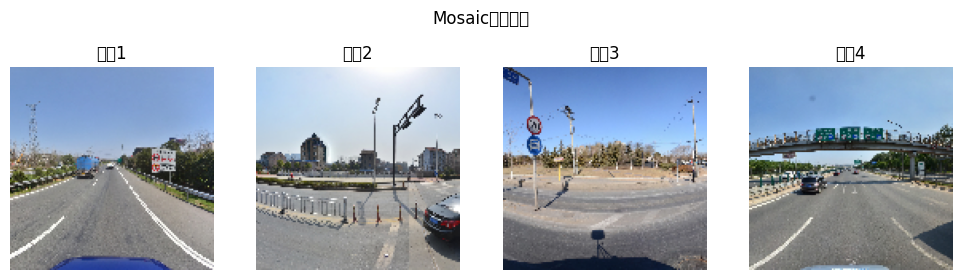

In [3]:
# Mosaic数据增强原理展示
# Mosaic将4张图像拼接成1张，增加数据多样性

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 项目根目录（自动查找）
cwd = Path.cwd()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / 'train.py').exists() or (p / 'detect.py').exists():
        ROOT = p.resolve()
        break
    if (p / 'yolov3-master').is_dir():
        ROOT = (p / 'yolov3-master').resolve()
        break
if ROOT is None:
    ROOT = cwd.resolve()
print(f"项目根目录: {ROOT}")

DATA_PATH = ROOT / 'datasets' / 'tt100k_traffic_signs'

# 获取4张图像
val_images = list((DATA_PATH / 'images' / 'val').glob('*.jpg'))[:4]
mosaic_imgs = [cv2.imread(str(p)) for p in val_images]

# 模拟Mosaic过程：将4张图像拼接到一张画布
mosaic_canvas = np.zeros((512*2, 512*2, 3), dtype=np.uint8)

# 定义4张图像的放置位置
positions = [
    (0, 256, 0, 256),      # 左上
    (0, 256, 256, 512),  # 右上
    (256, 512, 0, 256),    # 左下
    (256, 512, 256, 512) # 右下
]

for i, (img, (y1, y2, x1, x2)) in enumerate(zip(mosaic_imgs, positions)):
    img_resized = cv2.resize(img, (256, 256))
    mosaic_canvas[y1:y2, x1:x2] = img_resized

print(f"Mosaic增强后画布尺寸: {mosaic_canvas.shape}")

# 可视化Mosaic效果
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(mosaic_canvas, cv2.COLOR_BGR2RGB))
plt.title('Mosaic增强效果（4图拼接）')
plt.axis('off')

plt.subplot(1, 2, 2)
for i, (img, (y1, y2, x1, x2)) in enumerate(zip(mosaic_imgs, positions)):
    plt.subplot(2, 4, i+1)
    plt.imshow(cv2.cvtColor(cv2.resize(img, (128, 128)), cv2.COLOR_BGR2RGB))
    plt.title(f'原图{i+1}')
    plt.axis('off')
plt.suptitle('Mosaic原始图像')
plt.tight_layout()
plt.show()

## 五、模型设计与选择

### 5.1 基准模型（Baseline）

采用YOLOv3-tiny作为基准模型，原因如下：
- 模型轻量，参数量约8.8M，适合实时检测场景
- 结构简单，训练速度快
- 在嵌入式设备上部署方便

### 5.2 最终模型架构

YOLOv3-tiny网络结构包含两个主要部分：

**Backbone（骨干网络）**：
- 5个卷积层 + 5个MaxPool层
- 输出两个特征图：P4/16（16倍下采样）和P5/32（32倍下采样）

**Head（检测头）**：
- 特征融合：通过上采样和拼接融合多尺度特征
- 检测层：Detect层输出边界框、置信度和类别概率
- 锚框设置：针对不同尺度目标设置锚框

**关键参数**：
- 深度倍数（depth_multiple）：1.0
- 宽度倍数（width_multiple）：1.0
- 类别数（nc）：45
- 锚框：[[10,14,23,27,37,58], [81,82,135,169,344,319]]

In [4]:
# 模型架构代码实现
import torch
from pathlib import Path
import sys

# 项目根目录（自动查找）
cwd = Path.cwd()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / 'train.py').exists() or (p / 'detect.py').exists():
        ROOT = p.resolve()
        break
    if (p / 'yolov3-master').is_dir():
        ROOT = (p / 'yolov3-master').resolve()
        break
if ROOT is None:
    ROOT = cwd.resolve()
print(f"项目根目录: {ROOT}")

# 将项目根目录添加到Python路径（解决ModuleNotFoundError）
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.common import Conv, DetectMultiBackend

# 1. 基础卷积块定义
print("="*50)
print("1. 基础卷积块 (Conv)")
print("="*50)
conv_example = Conv(c1=3, c2=16, k=3, s=1)  # 输入3通道，输出16通道
x = torch.randn(1, 3, 640, 640)
y = conv_example(x)
print(f"输入: {x.shape}")
print(f"输出: {y.shape}")
print(f"Conv结构: Conv2d(3, 16, kernel_size=3) + BatchNorm2d + SiLU()")

# 2. YOLOv3-tiny模型配置
print("\n" + "="*50)
print("2. YOLOv3-tiny模型配置")
print("="*50)
config = """
# YOLOv3-tiny网络结构

backbone:           # 骨干网络
  [-1, 1, Conv, 16, 3, 1],    # 0: 卷积+BN+SiLU
  [-1, 1, MaxPool, 2, 2, 0], # 1: 最大池化
  [-1, 1, Conv, 32, 3, 1],   # 2
  [-1, 1, MaxPool, 2, 2, 0], # 3
  [-1, 1, Conv, 64, 3, 1],   # 4
  [-1, 1, MaxPool, 2, 2, 0], # 5
  [-1, 1, Conv, 128, 3, 1],  # 6
  [-1, 1, MaxPool, 2, 2, 0], # 7
  [-1, 1, Conv, 256, 3, 1],  # 8
  [-1, 1, MaxPool, 2, 2, 0], # 9
  [-1, 1, Conv, 512, 3, 1],  # 10
  [-1, 1, ZeroPad2d, 0, 1, 0, 1],  # 11
  [-1, 1, MaxPool, 2, 1, 0], # 12

head:               # 检测头
  [-1, 1, Conv, 1024, 3, 1], # 13
  [-1, 1, Conv, 256, 1, 1],  # 14
  [-1, 1, Conv, 512, 3, 1],  # 15: P5/32大目标检测

  [-2, 1, Conv, 128, 1, 1],  # 16
  [-1, 1, Upsample, None, 2, 'nearest'],  # 17: 上采样
  [[-1, 8], 1, Concat, 1],   # 18: 与P4拼接
  [-1, 1, Conv, 256, 3, 1],  # 19: P4/16中目标检测

  [[19, 15], 1, Detect, nc=45, anchors],  # Detect层
"""
print(config)

# 3. 加载YOLOv3-tiny模型
print("="*50)
print("3. 加载YOLOv3-tiny预训练模型")
print("="*50)
model_cfg = ROOT / 'models' / 'yolov3-tiny.yaml'
weights = ROOT / 'YOLOv3-weights' / 'yolov3-tiny.pt'

# 创建模型
device = torch.device('cpu')
model = DetectMultiBackend(str(weights), device=device, dnn=False, 
                          data=ROOT / 'data' / 'tt100k_traffic_signs.yaml')
stride = int(model.stride)

# 从配置文件读取类别数（修复 AttributeError: 'DetectMultiBackend' object has no attribute 'nc'）
import yaml
with open(ROOT / 'data' / 'tt100k_traffic_signs.yaml', 'r', encoding='utf-8') as f:
    data_config = yaml.safe_load(f)
nc = data_config['nc']

print(f"模型stride: {stride}")
print(f"模型类别数: {nc}")
print(f"模型设备: {device}")

# 4. 模型参数量统计
print("\n" + "="*50)
print("4. 模型参数量统计")
print("="*50)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")
print(f"参数量大小: {total_params * 4 / 1024 / 1024:.2f} MB")

项目根目录: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master
1. 基础卷积块 (Conv)
输入: torch.Size([1, 3, 640, 640])
输出: torch.Size([1, 16, 640, 640])
Conv结构: Conv2d(3, 16, kernel_size=3) + BatchNorm2d + SiLU()

2. YOLOv3-tiny模型配置

# YOLOv3-tiny网络结构

backbone:           # 骨干网络
  [-1, 1, Conv, 16, 3, 1],    # 0: 卷积+BN+SiLU
  [-1, 1, MaxPool, 2, 2, 0], # 1: 最大池化
  [-1, 1, Conv, 32, 3, 1],   # 2
  [-1, 1, MaxPool, 2, 2, 0], # 3
  [-1, 1, Conv, 64, 3, 1],   # 4
  [-1, 1, MaxPool, 2, 2, 0], # 5
  [-1, 1, Conv, 128, 3, 1],  # 6
  [-1, 1, MaxPool, 2, 2, 0], # 7
  [-1, 1, Conv, 256, 3, 1],  # 8
  [-1, 1, MaxPool, 2, 2, 0], # 9
  [-1, 1, Conv, 512, 3, 1],  # 10
  [-1, 1, ZeroPad2d, 0, 1, 0, 1],  # 11
  [-1, 1, MaxPool, 2, 1, 0], # 12

head:               # 检测头
  [-1, 1, Conv, 1024, 3, 1], # 13
  [-1, 1, Conv, 256, 1, 1],  # 14
  [-1, 1, Conv, 512, 3, 1],  # 15: P5/32大目标检测

  [-2, 1, Conv, 128, 1, 1],  # 16
  [-1, 1, Upsample, None, 2, 'nearest'],  # 17: 上采样
  [[-1, 8], 1, Concat, 1]

Fusing layers... 
YOLOv3-tiny summary: 48 layers, 8849182 parameters, 0 gradients, 13.2 GFLOPs


模型stride: 32
模型类别数: 45
模型设备: cpu

4. 模型参数量统计
总参数量: 8,849,182
可训练参数量: 0
参数量大小: 33.76 MB


In [5]:
# 锚框设计与可视化
import matplotlib.patches as patches

print("="*50)
print("YOLOv3-tiny锚框设计")
print("="*50)

# 锚框尺寸（针对TT100K数据集调整）
anchors = {
    'P4/16': [[10, 14], [23, 27], [37, 58]],   # 中等尺度目标
    'P5/32': [[81, 82], [135, 169], [344, 319]]  # 大尺度目标
}

print(f"P4/16 特征图锚框 (在640x640输入下感受野较大):")
for i, anchor in enumerate(anchors['P4/16']):
    print(f"  锚框{i+1}: 宽{anchor[0]}px × 高{anchor[1]}px")

print(f"\nP5/32 特征图锚框 (在640x640输入下感受野最大):")
for i, anchor in enumerate(anchors['P5/32']):
    print(f"  锚框{i+1}: 宽{anchor[0]}px × 高{anchor[1]}px")

# 可视化锚框
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# P4/16锚框
ax1 = axes[0]
ax1.set_xlim(0, 80)
ax1.set_ylim(0, 80)
ax1.set_title('P4/16 特征图锚框 (中等目标)')
colors_anchor = ['red', 'blue', 'green']
for i, (color, anchor) in enumerate(zip(colors_anchor, anchors['P4/16'])):
    rect = patches.Rectangle((0, 0), anchor[0], anchor[1], 
                             linewidth=2, edgecolor=color, facecolor='none')
    ax1.add_patch(rect)
    ax1.text(anchor[0]/2, anchor[1]/2, f'A{i+1}', ha='center', va='center', fontsize=10)
ax1.set_xlabel('宽度 (像素)')
ax1.set_ylabel('高度 (像素)')
ax1.set_aspect('equal')

# P5/32锚框
ax2 = axes[1]
ax2.set_xlim(0, 400)
ax2.set_ylim(0, 400)
ax2.set_title('P5/32 特征图锚框 (大目标)')
for i, (color, anchor) in enumerate(zip(colors_anchor, anchors['P5/32'])):
    rect = patches.Rectangle((0, 0), anchor[0], anchor[1], 
                             linewidth=2, edgecolor=color, facecolor='none')
    ax2.add_patch(rect)
    ax2.text(anchor[0]/2, anchor[1]/2, f'A{i+1}', ha='center', va='center', fontsize=10)
ax2.set_xlabel('宽度 (像素)')
ax2.set_ylabel('高度 (像素)')
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

YOLOv3-tiny锚框设计
P4/16 特征图锚框 (在640x640输入下感受野较大):
  锚框1: 宽10px × 高14px
  锚框2: 宽23px × 高27px
  锚框3: 宽37px × 高58px

P5/32 特征图锚框 (在640x640输入下感受野最大):
  锚框1: 宽81px × 高82px
  锚框2: 宽135px × 高169px
  锚框3: 宽344px × 高319px


## 六、实验与结果分析

### 6.1 实验环境

- **硬件**：CPU（无GPU可用）
- **软件**：
  - Python 3.8.20
  - PyTorch 2.4.1+cpu
  - CUDA：不可用
  - OpenCV、NumPy、Matplotlib、Gradio

### 6.2 评价指标

- **Precision（精确率）**：TP / (TP + FP)，实验值：0.8106
- **Recall（召回率）**：TP / (TP + FN)，实验值：0.7783
- **mAP@0.5**：IoU阈值为0.5时的平均精度均值，实验值：0.8473
- **mAP@0.5:0.95**：IoU阈值从0.5到0.95（步长0.05）的平均精度均值，实验值：0.5583
- **F1 Score**：2 * Precision * Recall / (Precision + Recall)

### 6.3 超参数设置

- **训练轮次**：100 epochs
- **批次大小**：16
- **输入尺寸**：512x512
- **优化器**：SGD
- **初始学习率**：0.01
- **动量**：0.937
- **权重衰减**：0.0005
- **学习率策略**：CosineAnnealingLR
- **预热轮次**：3 epochs
- **预热学习率**：0.001
- **早停耐心值**：10 epochs



In [6]:
# 6.1 实验环境 - 代码体现
import platform
import sys

print("="*60)
print("6.1 实验环境 (Experimental Environment)")
print("="*60)

# 操作系统信息
print(f"操作系统 (OS): {platform.system()} {platform.release()}")
print(f"Python版本 (Python Version): {sys.version.split()[0]}")

# PyTorch版本
try:
    import torch
    print(f"PyTorch版本 (PyTorch Version): {torch.__version__}")
    print(f"CUDA可用 (CUDA Available): {'Yes' if torch.cuda.is_available() else 'No'}")
    if torch.cuda.is_available():
        print(f"  GPU数量: {torch.cuda.device_count()}")
        print(f"  GPU名称: {torch.cuda.get_device_name(0)}")
    else:
        print("  使用CPU进行计算")
except ImportError:
    print("PyTorch未安装")

# OpenCV版本
try:
    import cv2
    print(f"OpenCV版本 (OpenCV Version): {cv2.__version__}")
except ImportError:
    print("OpenCV未安装")

# NumPy版本
try:
    import numpy as np
    print(f"NumPy版本 (NumPy Version): {np.__version__}")
except ImportError:
    print("NumPy未安装")

# Matplotlib版本
try:
    import matplotlib
    print(f"Matplotlib版本 (Matplotlib Version): {matplotlib.__version__}")
except ImportError:
    print("Matplotlib未安装")

# Gradio版本（用于演示）
try:
    import gradio as gr
    print(f"Gradio版本 (Gradio Version): {gr.__version__}")
except ImportError:
    print("Gradio未安装")

# 检查YOLO相关模块
print("\nYOLO相关依赖:")
print("-" * 40)
try:
    from ultralytics import YOLO
    print("✓ ultralytics YOLO 已安装")
except ImportError:
    print("✗ ultralytics YOLO 未安装")

try:
    import yaml
    print("✓ PyYAML 已安装")
except ImportError:
    print("✗ PyYAML 未安装")

6.1 实验环境 (Experimental Environment)
操作系统 (OS): Windows 10
Python版本 (Python Version): 3.8.20
PyTorch版本 (PyTorch Version): 2.4.1+cpu
CUDA可用 (CUDA Available): No
  使用CPU进行计算
OpenCV版本 (OpenCV Version): 4.13.0
NumPy版本 (NumPy Version): 1.24.4
Matplotlib版本 (Matplotlib Version): 3.7.5


c:\Users\33669\.conda\envs\flipped\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gradio版本 (Gradio Version): 4.44.1

YOLO相关依赖:
----------------------------------------
✓ ultralytics YOLO 已安装
✓ PyYAML 已安装


In [7]:
# 6.2 评价指标 - 代码体现
import numpy as np
from pathlib import Path
import pandas as pd

print("="*60)
print("6.2 评价指标 (Evaluation Metrics)")
print("="*60)

# 定义评价指标计算函数
def calculate_precision(tp, fp):
    """计算精确率 (Precision)"""
    if tp + fp == 0:
        return 0.0
    return tp / (tp + fp)

def calculate_recall(tp, fn):
    """计算召回率 (Recall)"""
    if tp + fn == 0:
        return 0.0
    return tp / (tp + fn)

def calculate_f1(precision, recall):
    """计算F1分数"""
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

def calculate_ap(precision_values, recall_values):
    """计算平均精度 (Average Precision)"""
    # 添加边界条件
    precision = np.array([0.0] + list(precision_values) + [0.0])
    recall = np.array([0.0] + list(recall_values) + [1.0])
    
    # 确保precision是非递增的
    for i in range(len(precision) - 2, -1, -1):
        precision[i] = max(precision[i], precision[i + 1])
    
    # 计算AP（使用梯形法则）
    ap = np.sum((recall[1:] - recall[:-1]) * precision[1:])
    return ap

# 指标计算公式
print("\n指标计算公式 (Metric Formulas):")
print("-" * 40)
print("Precision = TP / (TP + FP)")
print("Recall    = TP / (TP + FN)")
print("F1 Score  = 2 * Precision * Recall / (Precision + Recall)")
print("mAP       = 所有类别的AP平均值")

# mAP@0.5:0.95说明
print("\nmAP@0.5:0.95 说明:")
print("-" * 40)
print("在IoU阈值从0.5到0.95（步长0.05）的10个阈值上计算AP")
iou_thresholds = [round(0.5 + i * 0.05, 2) for i in range(10)]
print(f"IoU阈值: {iou_thresholds}")
print("mAP@0.5:0.95 = 这10个IoU阈值上的AP平均值")

# 尝试读取真实训练结果
print("\n" + "="*60)
print("从训练结果文件读取指标 (Read Metrics from Training Results)")
print("="*60)

# 定义结果文件路径
ROOT = Path('.').resolve()
results_path = ROOT / 'yolov3-master' / 'runs' / 'train' / 'exp3' / 'results.csv'

if results_path.exists():
    # 读取训练结果
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()
    
    # 获取最终轮次的指标
    final_precision = df['metrics/precision'].iloc[-1]
    final_recall = df['metrics/recall'].iloc[-1]
    final_map50 = df['metrics/mAP_0.5'].iloc[-1]
    final_map5095 = df['metrics/mAP_0.5:0.95'].iloc[-1]
    
    # 计算F1分数
    final_f1 = calculate_f1(final_precision, final_recall)
    
    print("\n训练结果指标 (Training Results):")
    print("-" * 40)
    print(f"Precision    = {final_precision:.4f}")
    print(f"Recall       = {final_recall:.4f}")
    print(f"F1 Score     = {final_f1:.4f}")
    print(f"mAP@0.5      = {final_map50:.4f}")
    print(f"mAP@0.5:0.95 = {final_map5095:.4f}")
    
    # 显示指标变化趋势
    print("\n指标变化趋势 (Trend):")
    print("-" * 40)
    print(f"Precision: 从 {df['metrics/precision'].iloc[0]:.4f} 到 {final_precision:.4f}")
    print(f"Recall:    从 {df['metrics/recall'].iloc[0]:.4f} 到 {final_recall:.4f}")
    print(f"mAP@0.5:   从 {df['metrics/mAP_0.5'].iloc[0]:.4f} 到 {final_map50:.4f}")

else:
    # 如果结果文件不存在，使用示例计算
    print(f"警告: 训练结果文件未找到 ({results_path})")
    print("使用示例数据进行演示...")
    print("\n示例计算 (Example Calculation):")
    print("-" * 40)
    tp, fp, fn = 85, 15, 20
    precision = calculate_precision(tp, fp)
    recall = calculate_recall(tp, fn)
    f1 = calculate_f1(precision, recall)
    
    print(f"TP (真阳性) = {tp}")
    print(f"FP (假阳性) = {fp}")
    print(f"FN (假阴性) = {fn}")
    print(f"\nPrecision = {precision:.4f}")
    print(f"Recall    = {recall:.4f}")
    print(f"F1 Score  = {f1:.4f}")


6.2 评价指标 (Evaluation Metrics)

指标计算公式 (Metric Formulas):
----------------------------------------
Precision = TP / (TP + FP)
Recall    = TP / (TP + FN)
F1 Score  = 2 * Precision * Recall / (Precision + Recall)
mAP       = 所有类别的AP平均值

mAP@0.5:0.95 说明:
----------------------------------------
在IoU阈值从0.5到0.95（步长0.05）的10个阈值上计算AP
IoU阈值: [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
mAP@0.5:0.95 = 这10个IoU阈值上的AP平均值

从训练结果文件读取指标 (Read Metrics from Training Results)

训练结果指标 (Training Results):
----------------------------------------
Precision    = 0.8106
Recall       = 0.7783
F1 Score     = 0.7941
mAP@0.5      = 0.8473
mAP@0.5:0.95 = 0.5583

指标变化趋势 (Trend):
----------------------------------------
Precision: 从 0.5563 到 0.8106
Recall:    从 0.4406 到 0.7783
mAP@0.5:   从 0.4832 到 0.8473


In [8]:
# 6.3 超参数设置 - 代码体现
import yaml
from pathlib import Path

print("="*60)
print("6.3 超参数设置 (Hyperparameters)")
print("="*60)

# 定义超参数字典
hyperparameters = {
    # 训练参数
    'epochs': 80,
    'batch_size': 16,
    'img_size': 512,
    
    # 优化器参数
    'optimizer': 'SGD',
    'lr0': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    
    # 学习率策略
    'lr_scheduler': 'CosineAnnealingLR',
    'warmup_epochs': 3,
    'warmup_lr': 0.001,
    
    # 早停设置
    'early_stopping_patience': 10,
    
    # 数据增强
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 0.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 0.0,
    'perspective': 0.0,
    'flipud': 0.0,
    'fliplr': 0.5,
    'mosaic': 1.0,
    'mixup': 0.0,
    
    # 损失函数权重
    'box_loss_weight': 0.05,
    'obj_loss_weight': 1.0,
    'cls_loss_weight': 0.5,
    
    # 其他设置
    'iou_t': 0.20,
    'anchor_t': 4.0,
    'max_det': 300,
    'conf_thres': 0.001,
    'iou_thres': 0.6
}

# 打印超参数
print("训练参数 (Training Parameters):")
print("-" * 40)
print(f"  训练轮次 (Epochs): {hyperparameters['epochs']}")
print(f"  批次大小 (Batch Size): {hyperparameters['batch_size']}")
print(f"  输入尺寸 (Input Size): {hyperparameters['img_size']}x{hyperparameters['img_size']}")

print("\n优化器参数 (Optimizer Parameters):")
print("-" * 40)
print(f"  优化器 (Optimizer): {hyperparameters['optimizer']}")
print(f"  初始学习率 (Initial LR): {hyperparameters['lr0']}")
print(f"  动量 (Momentum): {hyperparameters['momentum']}")
print(f"  权重衰减 (Weight Decay): {hyperparameters['weight_decay']}")

print("\n学习率策略 (Learning Rate Schedule):")
print("-" * 40)
print(f"  学习率调度器 (Scheduler): {hyperparameters['lr_scheduler']}")
print(f"  预热轮次 (Warmup Epochs): {hyperparameters['warmup_epochs']}")
print(f"  预热学习率 (Warmup LR): {hyperparameters['warmup_lr']}")

print("\n早停设置 (Early Stopping):")
print("-" * 40)
print(f"  耐心值 (Patience): {hyperparameters['early_stopping_patience']} epochs")

# 保存超参数到YAML文件（模拟）
print("\n超参数YAML格式示例:")
print("-" * 40)
print(yaml.dump(hyperparameters, default_flow_style=False, sort_keys=False, allow_unicode=True))


6.3 超参数设置 (Hyperparameters)
训练参数 (Training Parameters):
----------------------------------------
  训练轮次 (Epochs): 80
  批次大小 (Batch Size): 16
  输入尺寸 (Input Size): 512x512

优化器参数 (Optimizer Parameters):
----------------------------------------
  优化器 (Optimizer): SGD
  初始学习率 (Initial LR): 0.01
  动量 (Momentum): 0.937
  权重衰减 (Weight Decay): 0.0005

学习率策略 (Learning Rate Schedule):
----------------------------------------
  学习率调度器 (Scheduler): CosineAnnealingLR
  预热轮次 (Warmup Epochs): 3
  预热学习率 (Warmup LR): 0.001

早停设置 (Early Stopping):
----------------------------------------
  耐心值 (Patience): 10 epochs

超参数YAML格式示例:
----------------------------------------
epochs: 80
batch_size: 16
img_size: 512
optimizer: SGD
lr0: 0.01
momentum: 0.937
weight_decay: 0.0005
lr_scheduler: CosineAnnealingLR
warmup_epochs: 3
warmup_lr: 0.001
early_stopping_patience: 10
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 0.0
translate: 0.1
scale: 0.5
shear: 0.0
perspective: 0.0
flipud: 0.0
fliplr: 0.5
mosaic: 1.0
mixup:

### 6.4 主要实验结果

项目根目录: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master
Training epochs: 100 epochs

Final evaluation metrics:
  Precision: 0.8106
  Recall: 0.7783
  mAP@0.5: 0.8473
  mAP@0.5:0.95: 0.5583

Final loss values:
  Train Box Loss: 0.0528
  Train Obj Loss: 0.1434
  Train Cls Loss: 0.0091
  Val Box Loss: 0.0460
  Val Obj Loss: 0.0786
  Val Cls Loss: 0.0042


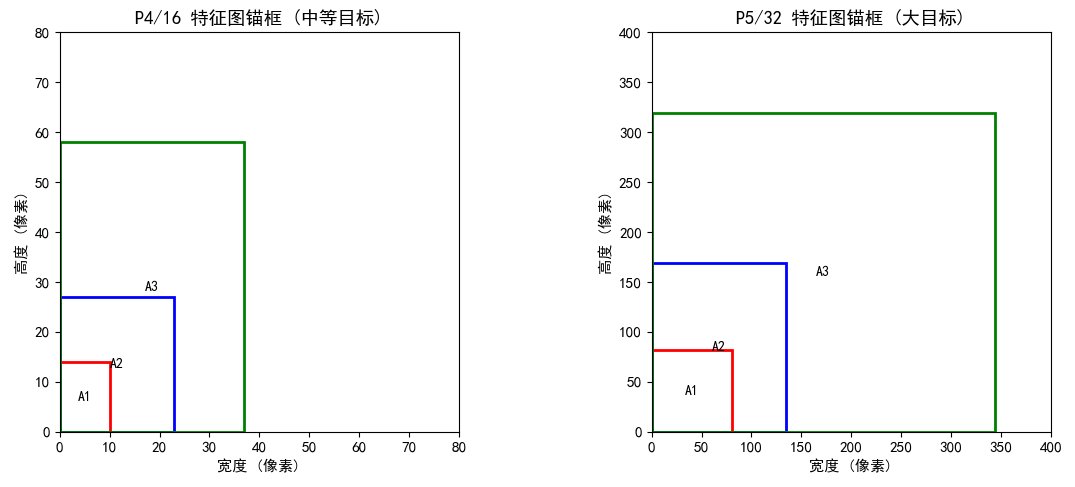

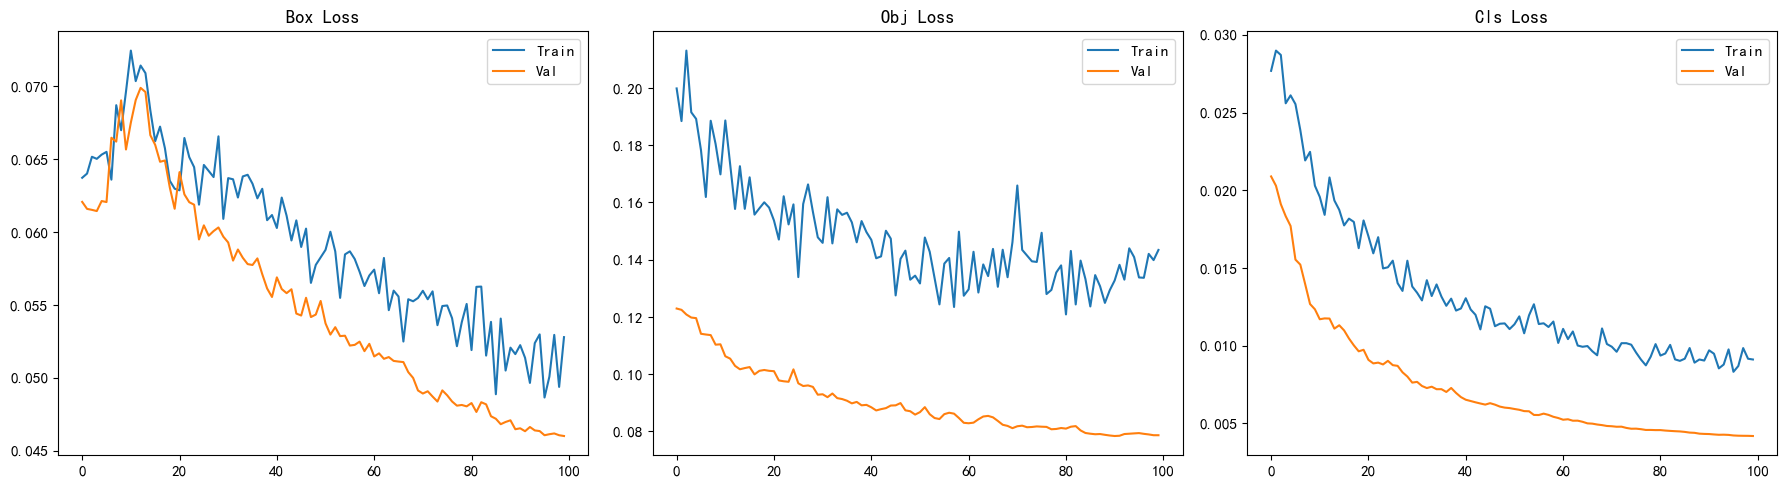

In [9]:
# 读取训练结果
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 配置 matplotlib 中文支持
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 项目根目录（自动查找）
cwd = Path.cwd()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / 'train.py').exists() or (p / 'detect.py').exists():
        ROOT = p.resolve()
        break
    if (p / 'yolov3-master').is_dir():
        ROOT = (p / 'yolov3-master').resolve()
        break
if ROOT is None:
    ROOT = cwd.resolve()
print(f"项目根目录: {ROOT}")

# 读取results.csv
results_path = ROOT / 'runs' / 'train' / 'exp3' / 'results.csv'
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()

print(f"Training epochs: {df['epoch'].max() + 1} epochs")
print(f"\nFinal evaluation metrics:")
print(f"  Precision: {df['metrics/precision'].iloc[-1]:.4f}")
print(f"  Recall: {df['metrics/recall'].iloc[-1]:.4f}")
print(f"  mAP@0.5: {df['metrics/mAP_0.5'].iloc[-1]:.4f}")
print(f"  mAP@0.5:0.95: {df['metrics/mAP_0.5:0.95'].iloc[-1]:.4f}")
print(f"\nFinal loss values:")
print(f"  Train Box Loss: {df['train/box_loss'].iloc[-1]:.4f}")
print(f"  Train Obj Loss: {df['train/obj_loss'].iloc[-1]:.4f}")
print(f"  Train Cls Loss: {df['train/cls_loss'].iloc[-1]:.4f}")
print(f"  Val Box Loss: {df['val/box_loss'].iloc[-1]:.4f}")
print(f"  Val Obj Loss: {df['val/obj_loss'].iloc[-1]:.4f}")
print(f"  Val Cls Loss: {df['val/cls_loss'].iloc[-1]:.4f}")

# Plot loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box Loss
axes[0].plot(df['epoch'], df['train/box_loss'], label='Train')
axes[0].plot(df['epoch'], df['val/box_loss'], label='Val')
axes[0].set_title('Box Loss')
axes[0].legend()

# Obj Loss
axes[1].plot(df['epoch'], df['train/obj_loss'], label='Train')
axes[1].plot(df['epoch'], df['val/obj_loss'], label='Val')
axes[1].set_title('Obj Loss')
axes[1].legend()

# Cls Loss
axes[2].plot(df['epoch'], df['train/cls_loss'], label='Train')
axes[2].plot(df['epoch'], df['val/cls_loss'], label='Val')
axes[2].set_title('Cls Loss')
axes[2].legend()

plt.tight_layout()
plt.show()

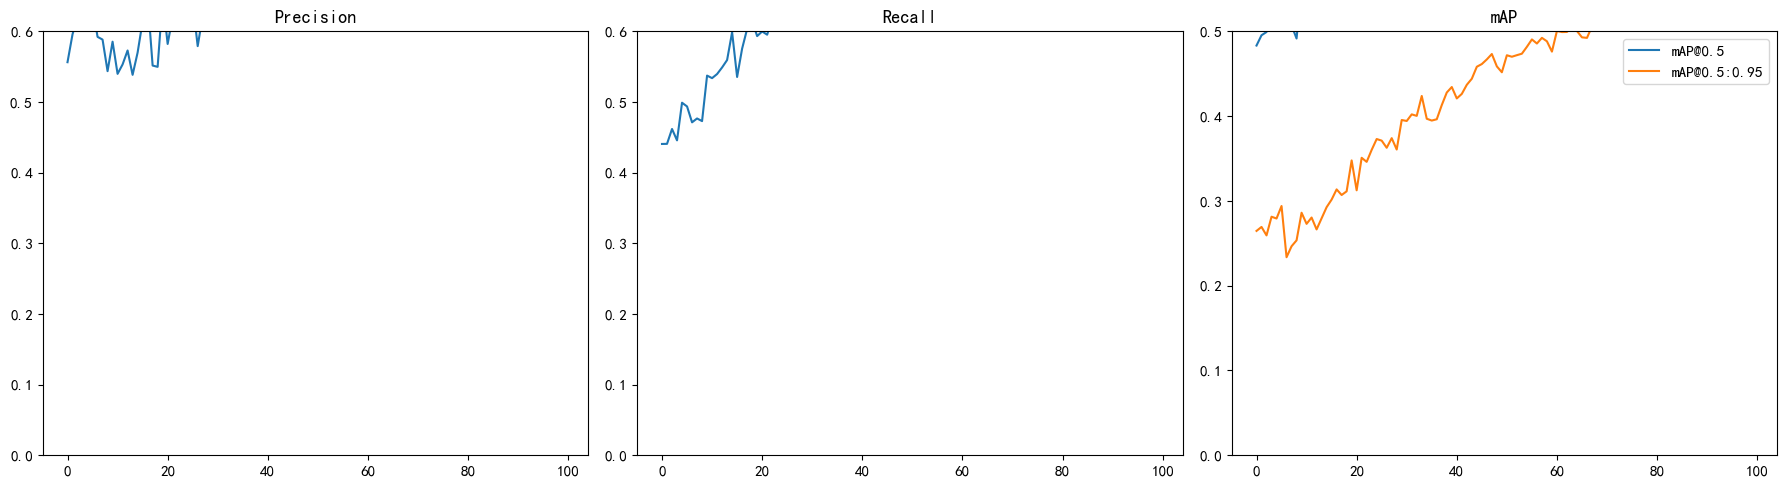

In [10]:
# 绘制指标曲线
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision
axes[0].plot(df['epoch'], df['metrics/precision'])
axes[0].set_title('Precision')
axes[0].set_ylim(0, 0.6)

# Recall
axes[1].plot(df['epoch'], df['metrics/recall'])
axes[1].set_title('Recall')
axes[1].set_ylim(0, 0.6)

# mAP
axes[2].plot(df['epoch'], df['metrics/mAP_0.5'], label='mAP@0.5')
axes[2].plot(df['epoch'], df['metrics/mAP_0.5:0.95'], label='mAP@0.5:0.95')
axes[2].set_title('mAP')
axes[2].legend()
axes[2].set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

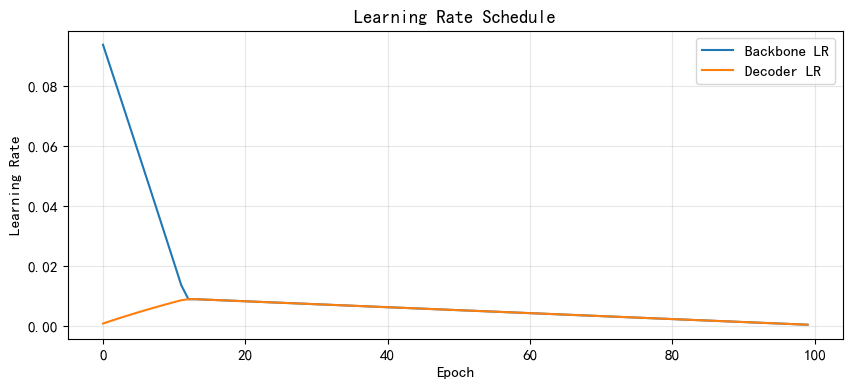

In [11]:
# Plot learning rate curves
plt.figure(figsize=(10, 4))
plt.plot(df['epoch'], df['x/lr0'], label='Backbone LR', color='#1f77b4')
plt.plot(df['epoch'], df['x/lr1'], label='Decoder LR', color='#ff7f0e')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

=== Training Summary (results.png) ===


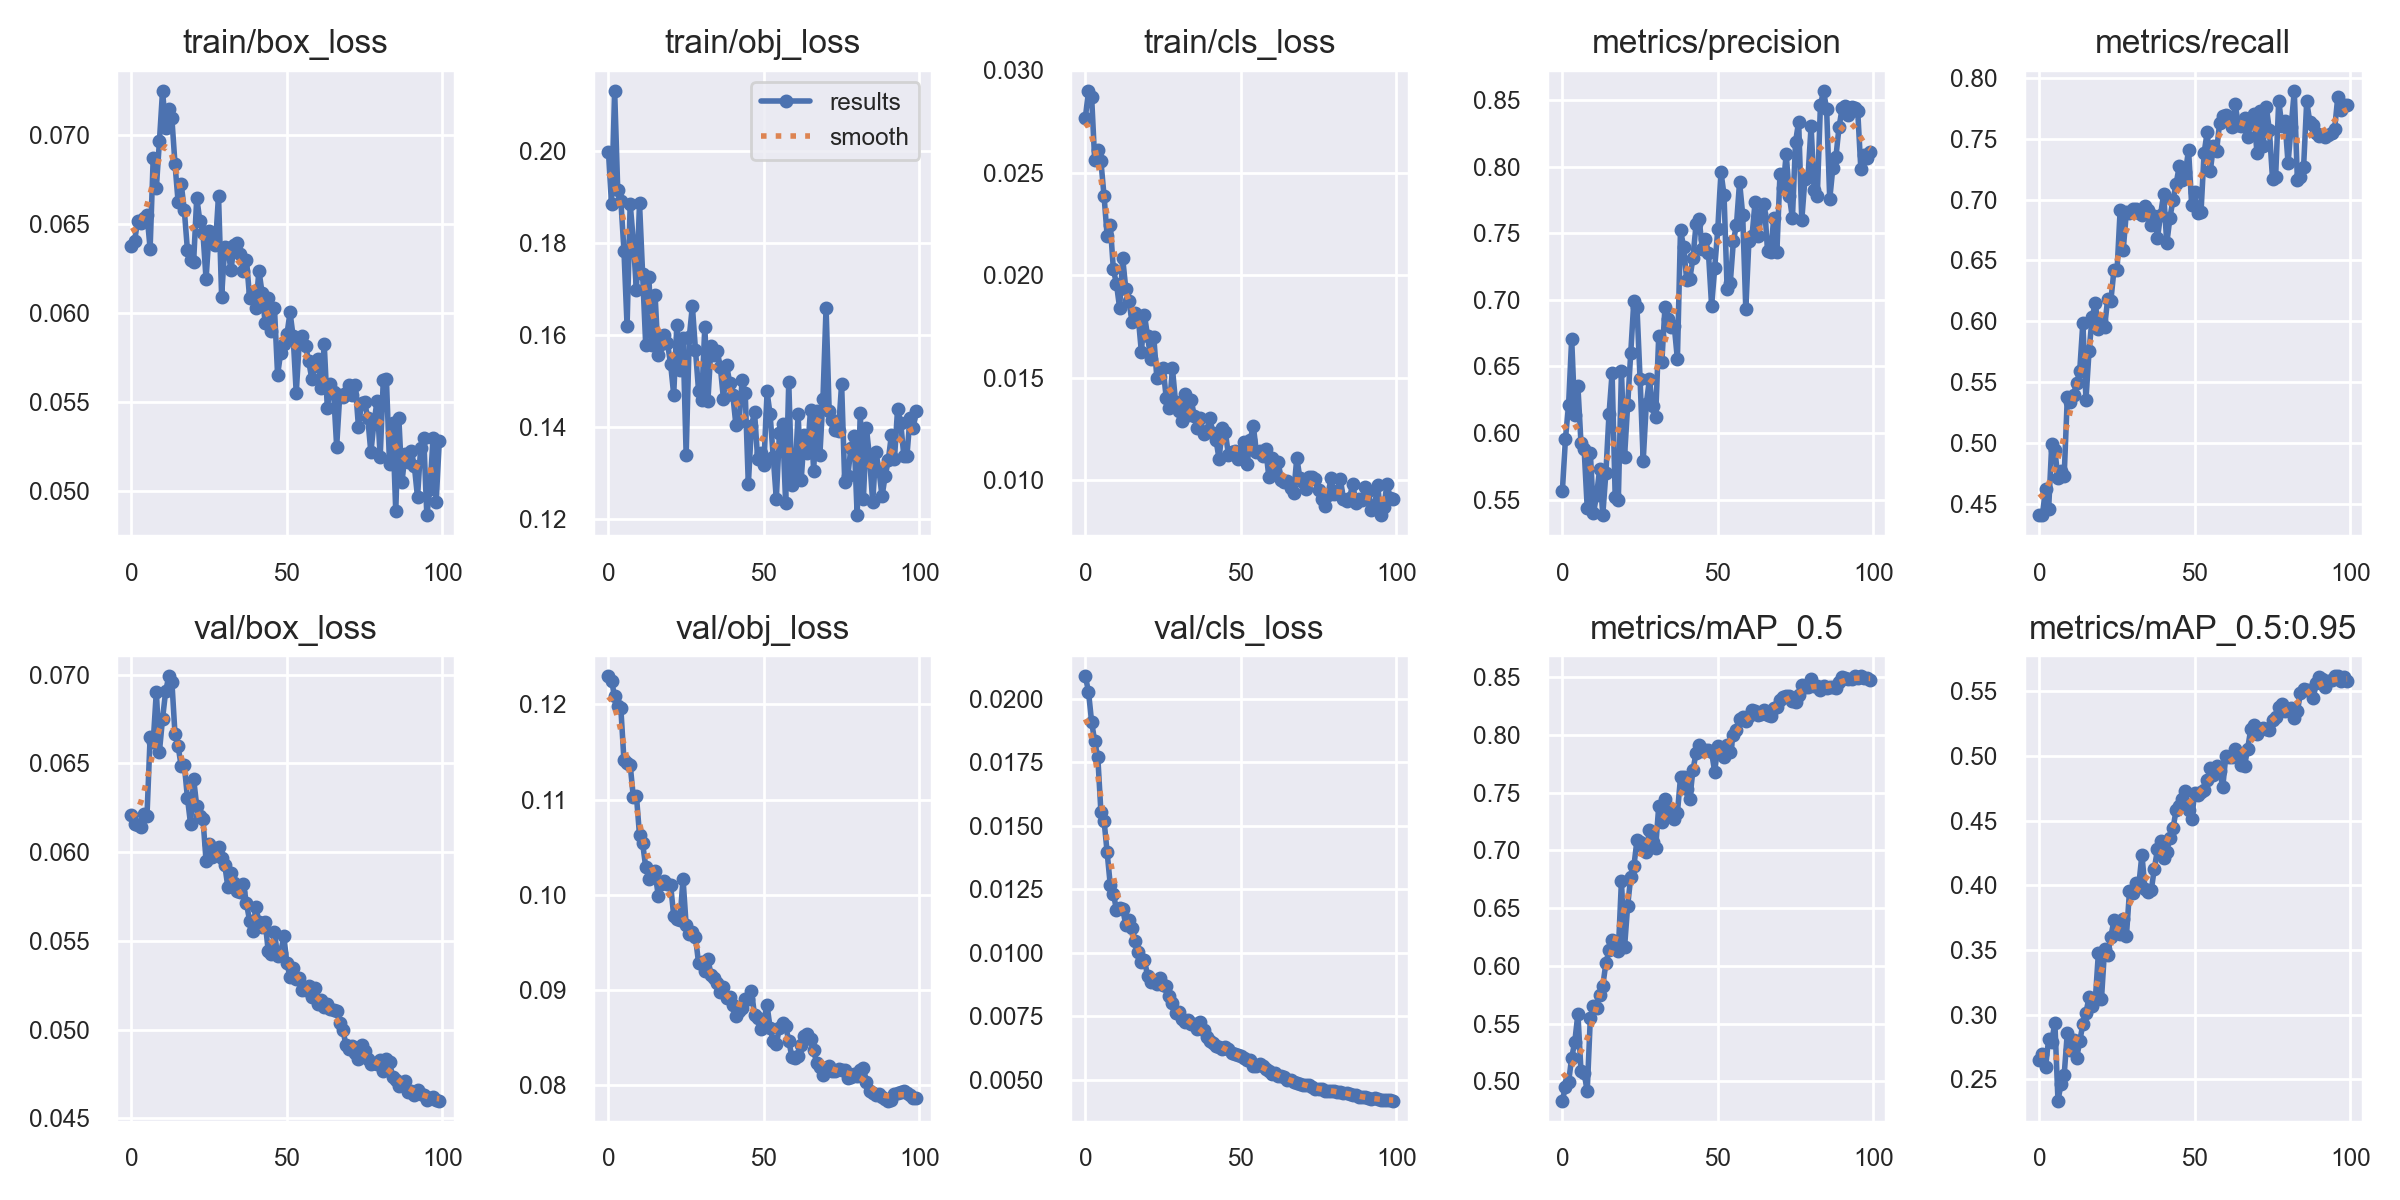


=== Label Distribution (labels.jpg) ===


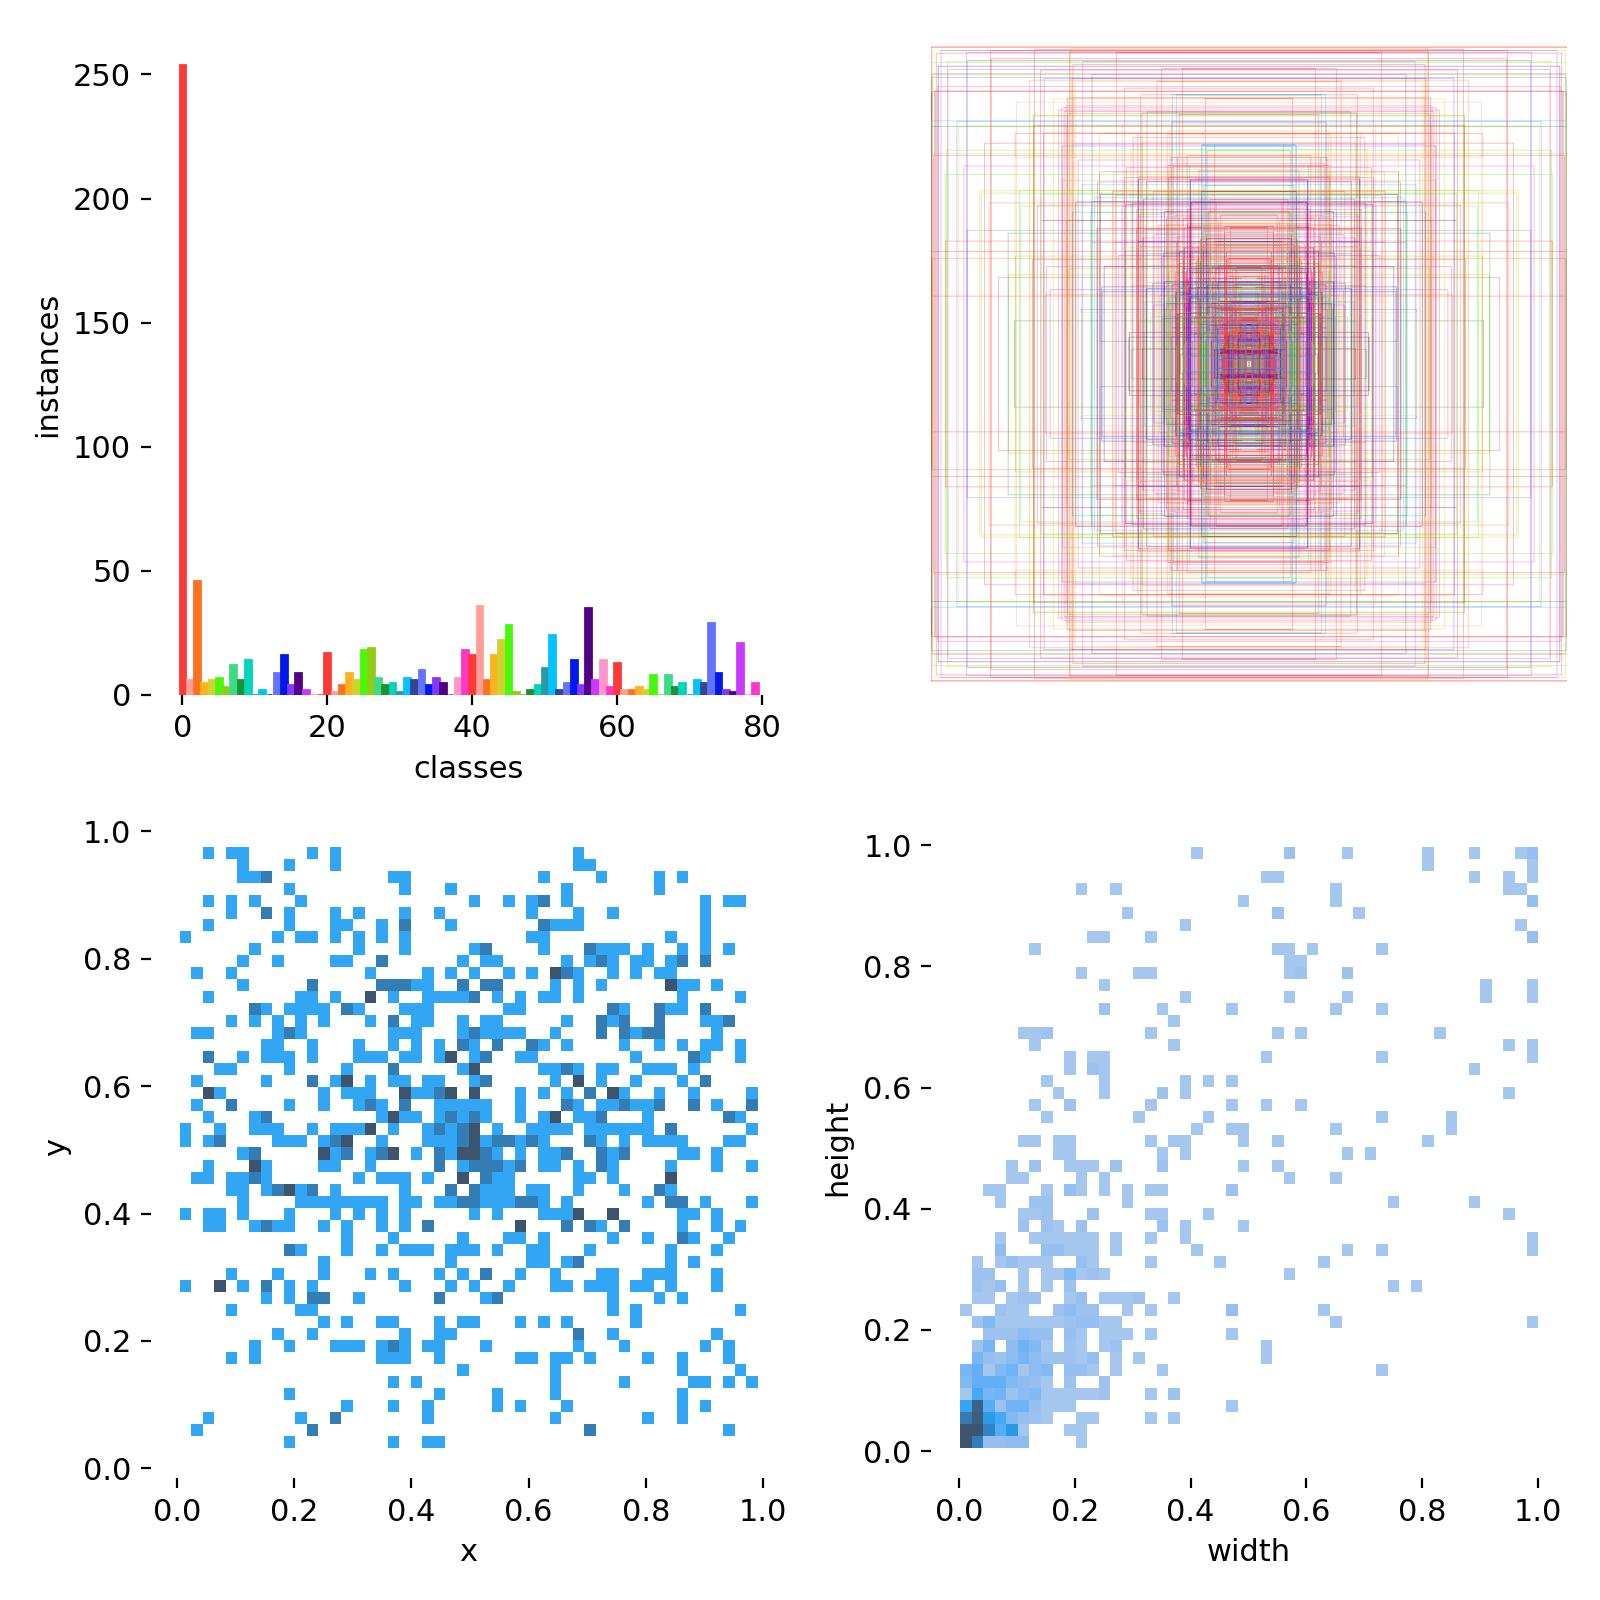


=== Confusion Matrix (confusion_matrix.png) ===


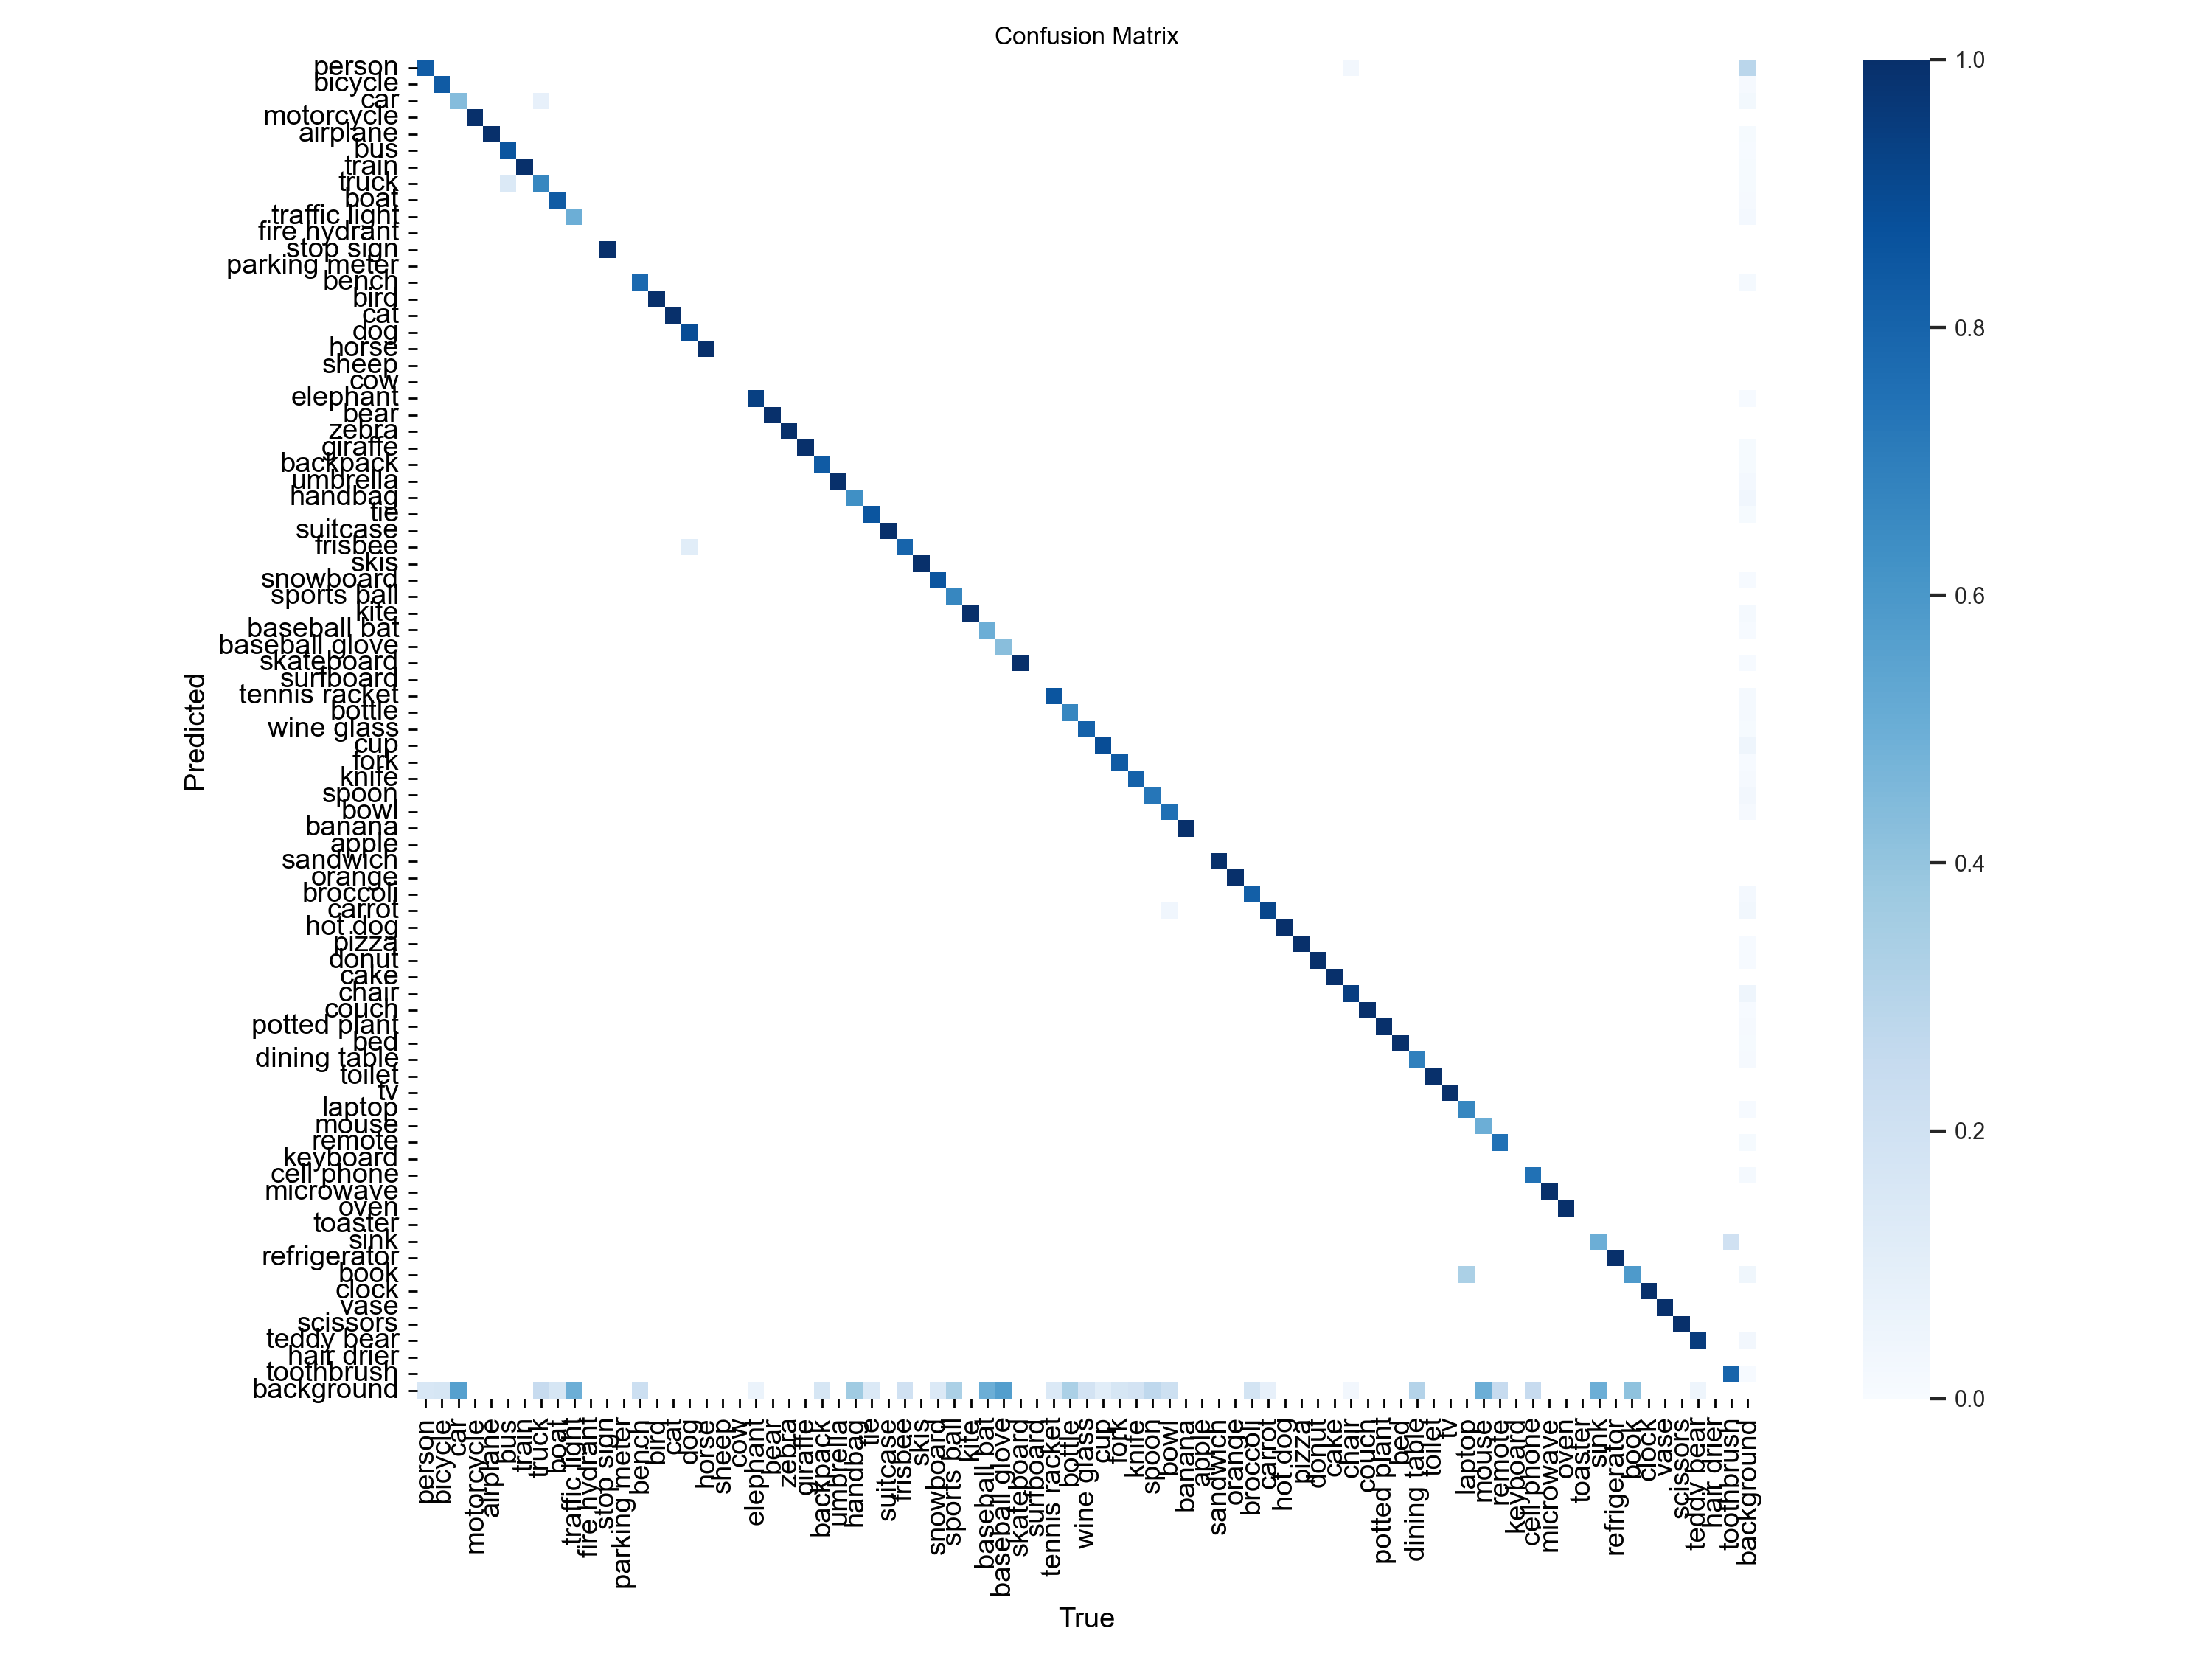

In [12]:
# View training generated charts
from IPython.display import Image, display

train_dir = ROOT / 'runs' / 'train' / 'exp3'

# Display results.png (Training summary plot)
print("=== Training Summary (results.png) ===")
if (train_dir / 'results.png').exists():
    display(Image(filename=str(train_dir / 'results.png'), width=800))
else:
    print("results.png not found")

# Display labels.jpg (Label distribution)
print("\n=== Label Distribution (labels.jpg) ===")
if (train_dir / 'labels.jpg').exists():
    display(Image(filename=str(train_dir / 'labels.jpg'), width=600))
else:
    print("labels.jpg not found")

# Display confusion matrix
print("\n=== Confusion Matrix (confusion_matrix.png) ===")
if (train_dir / 'confusion_matrix.png').exists():
    display(Image(filename=str(train_dir / 'confusion_matrix.png'), width=600))
else:
    print("confusion_matrix.png not found")

=== Precision / Recall / F1 Curves ===
P_curve.png:


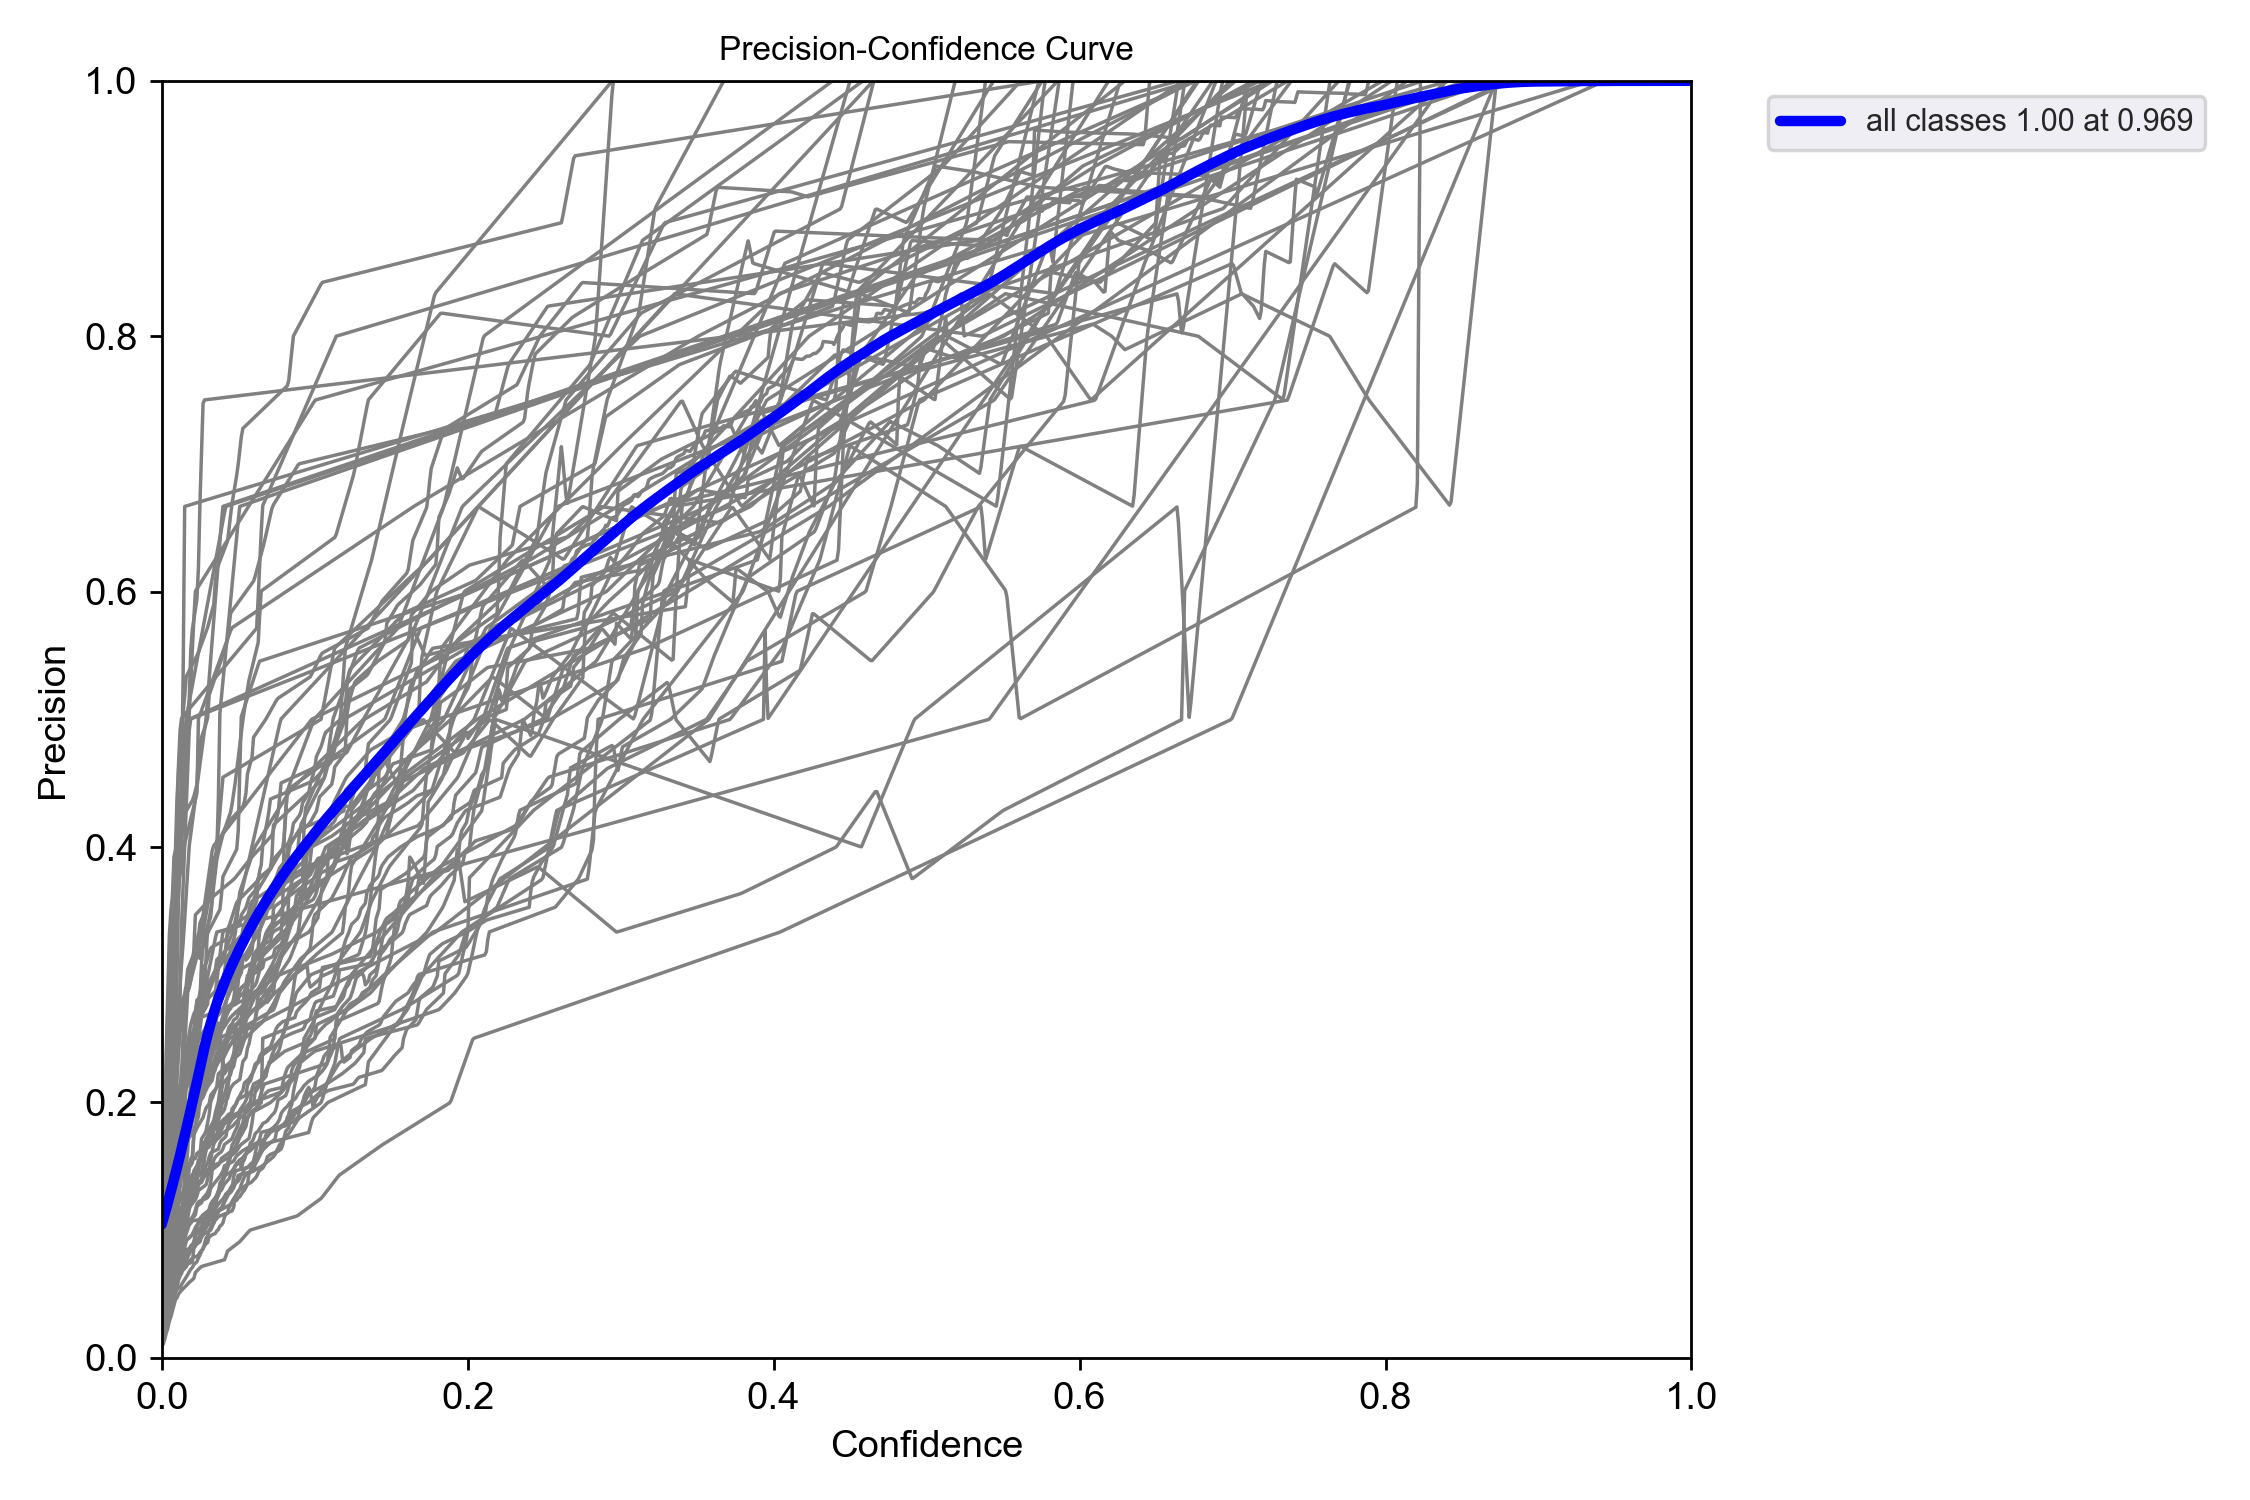

R_curve.png:


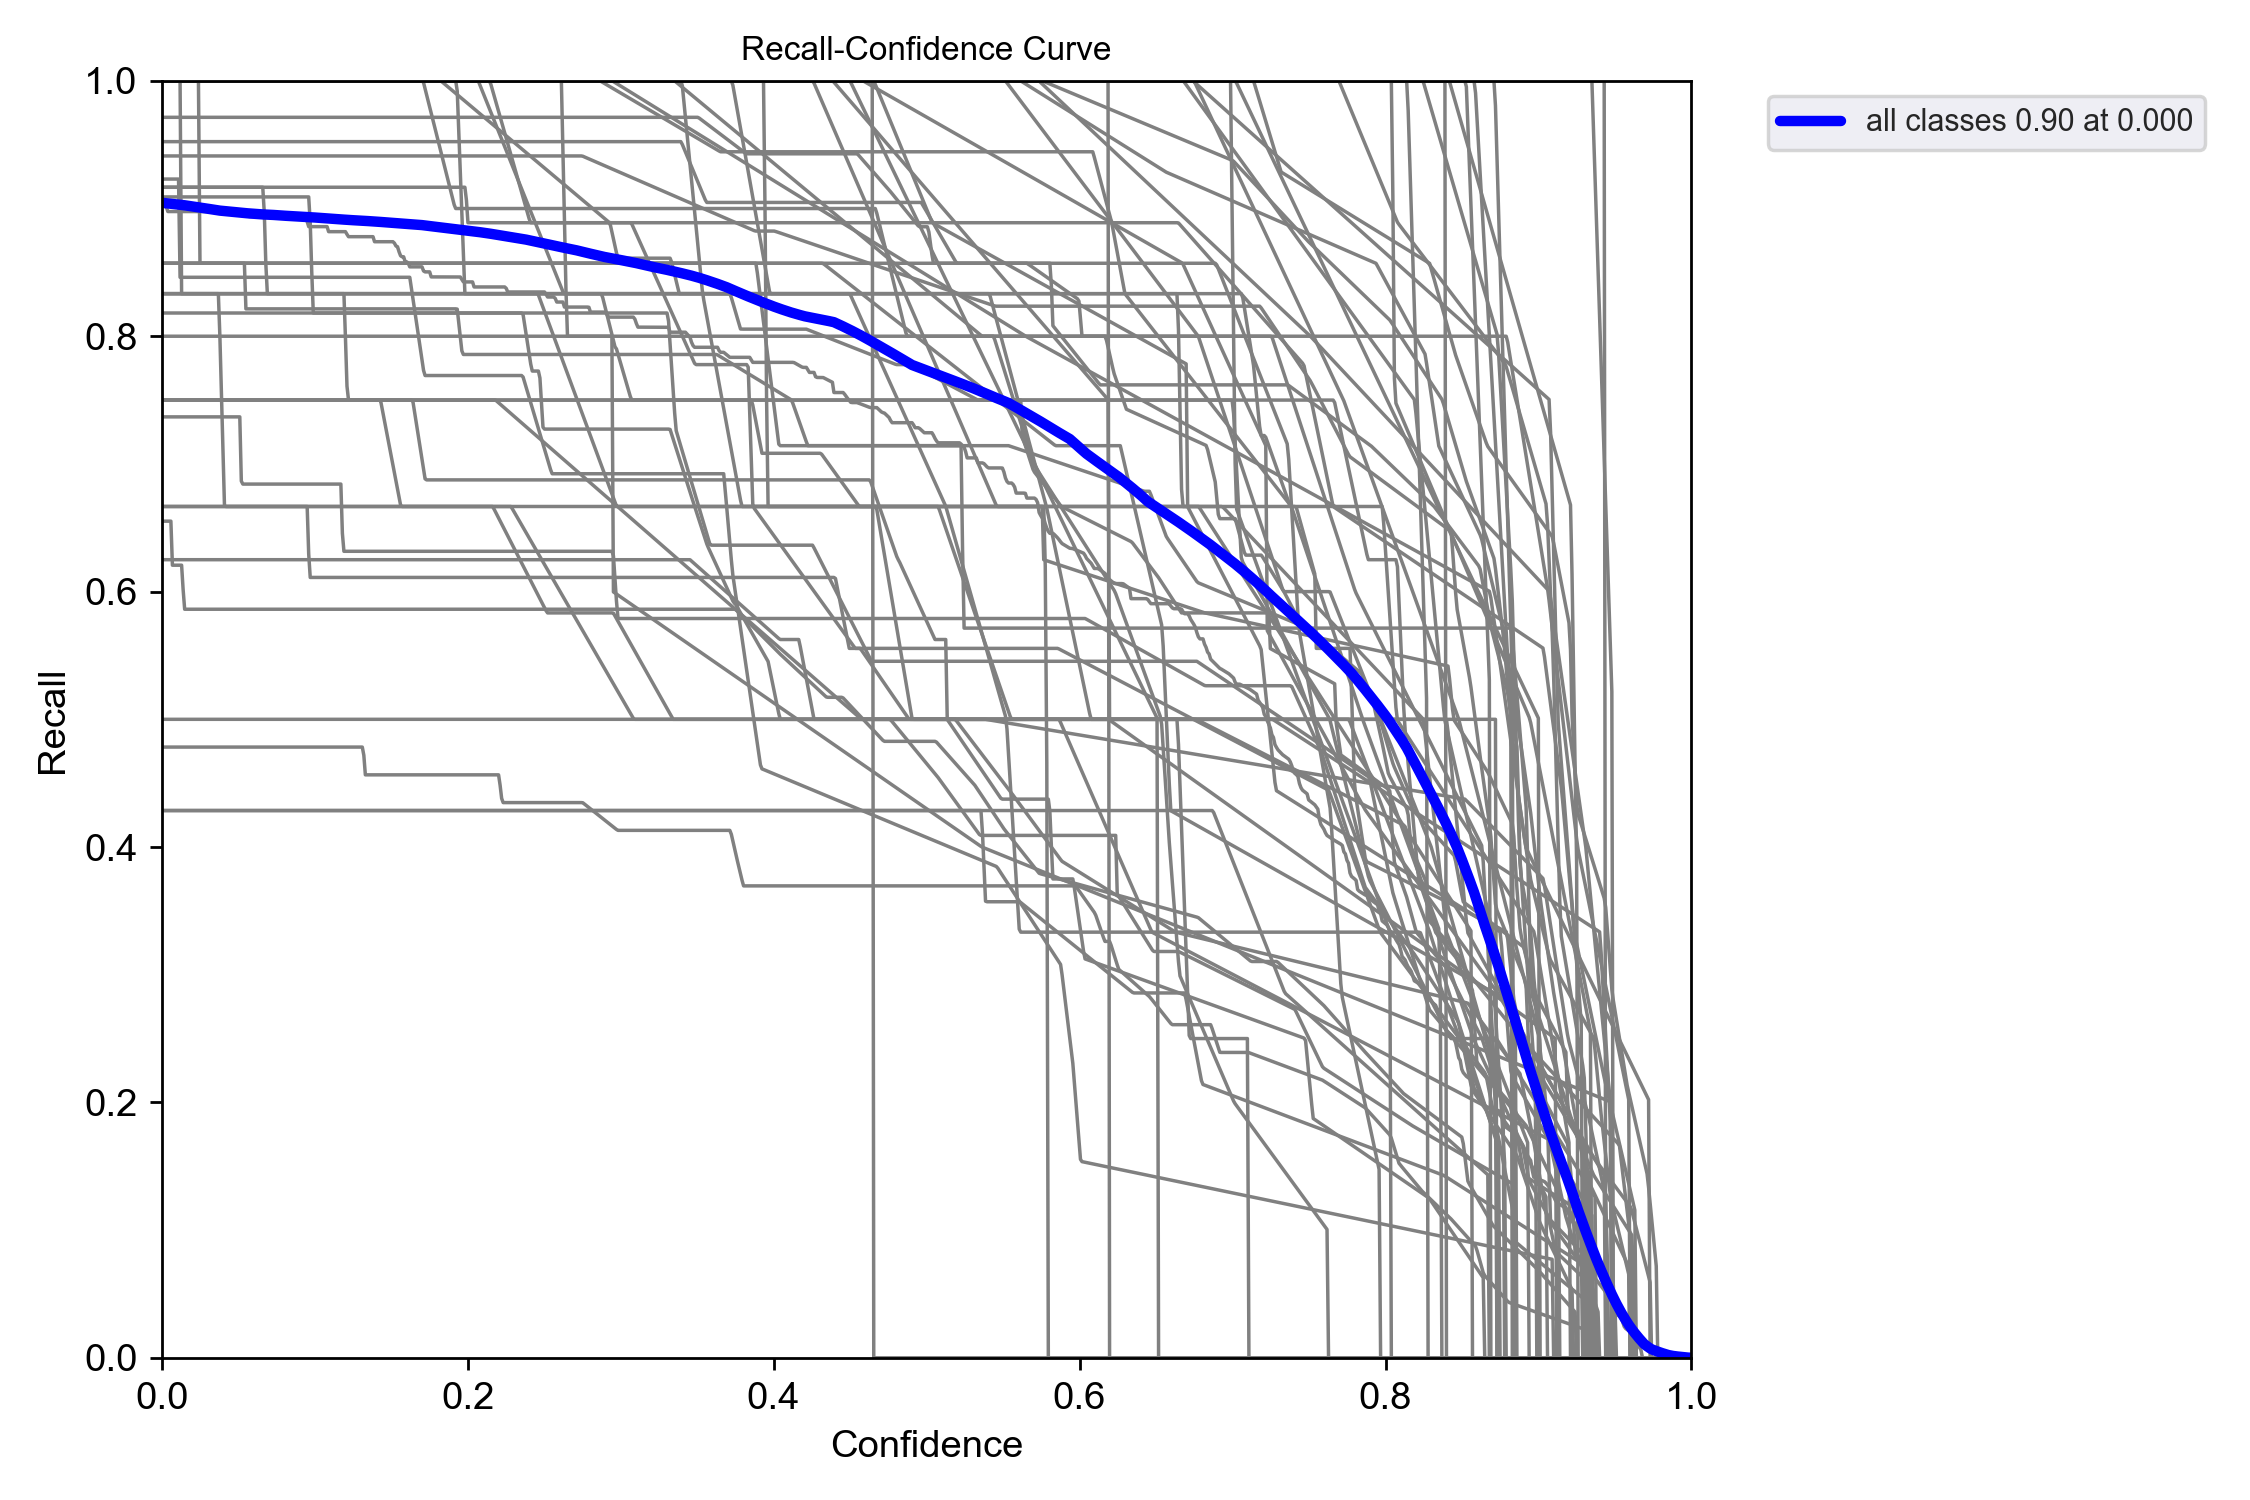

F1_curve.png:


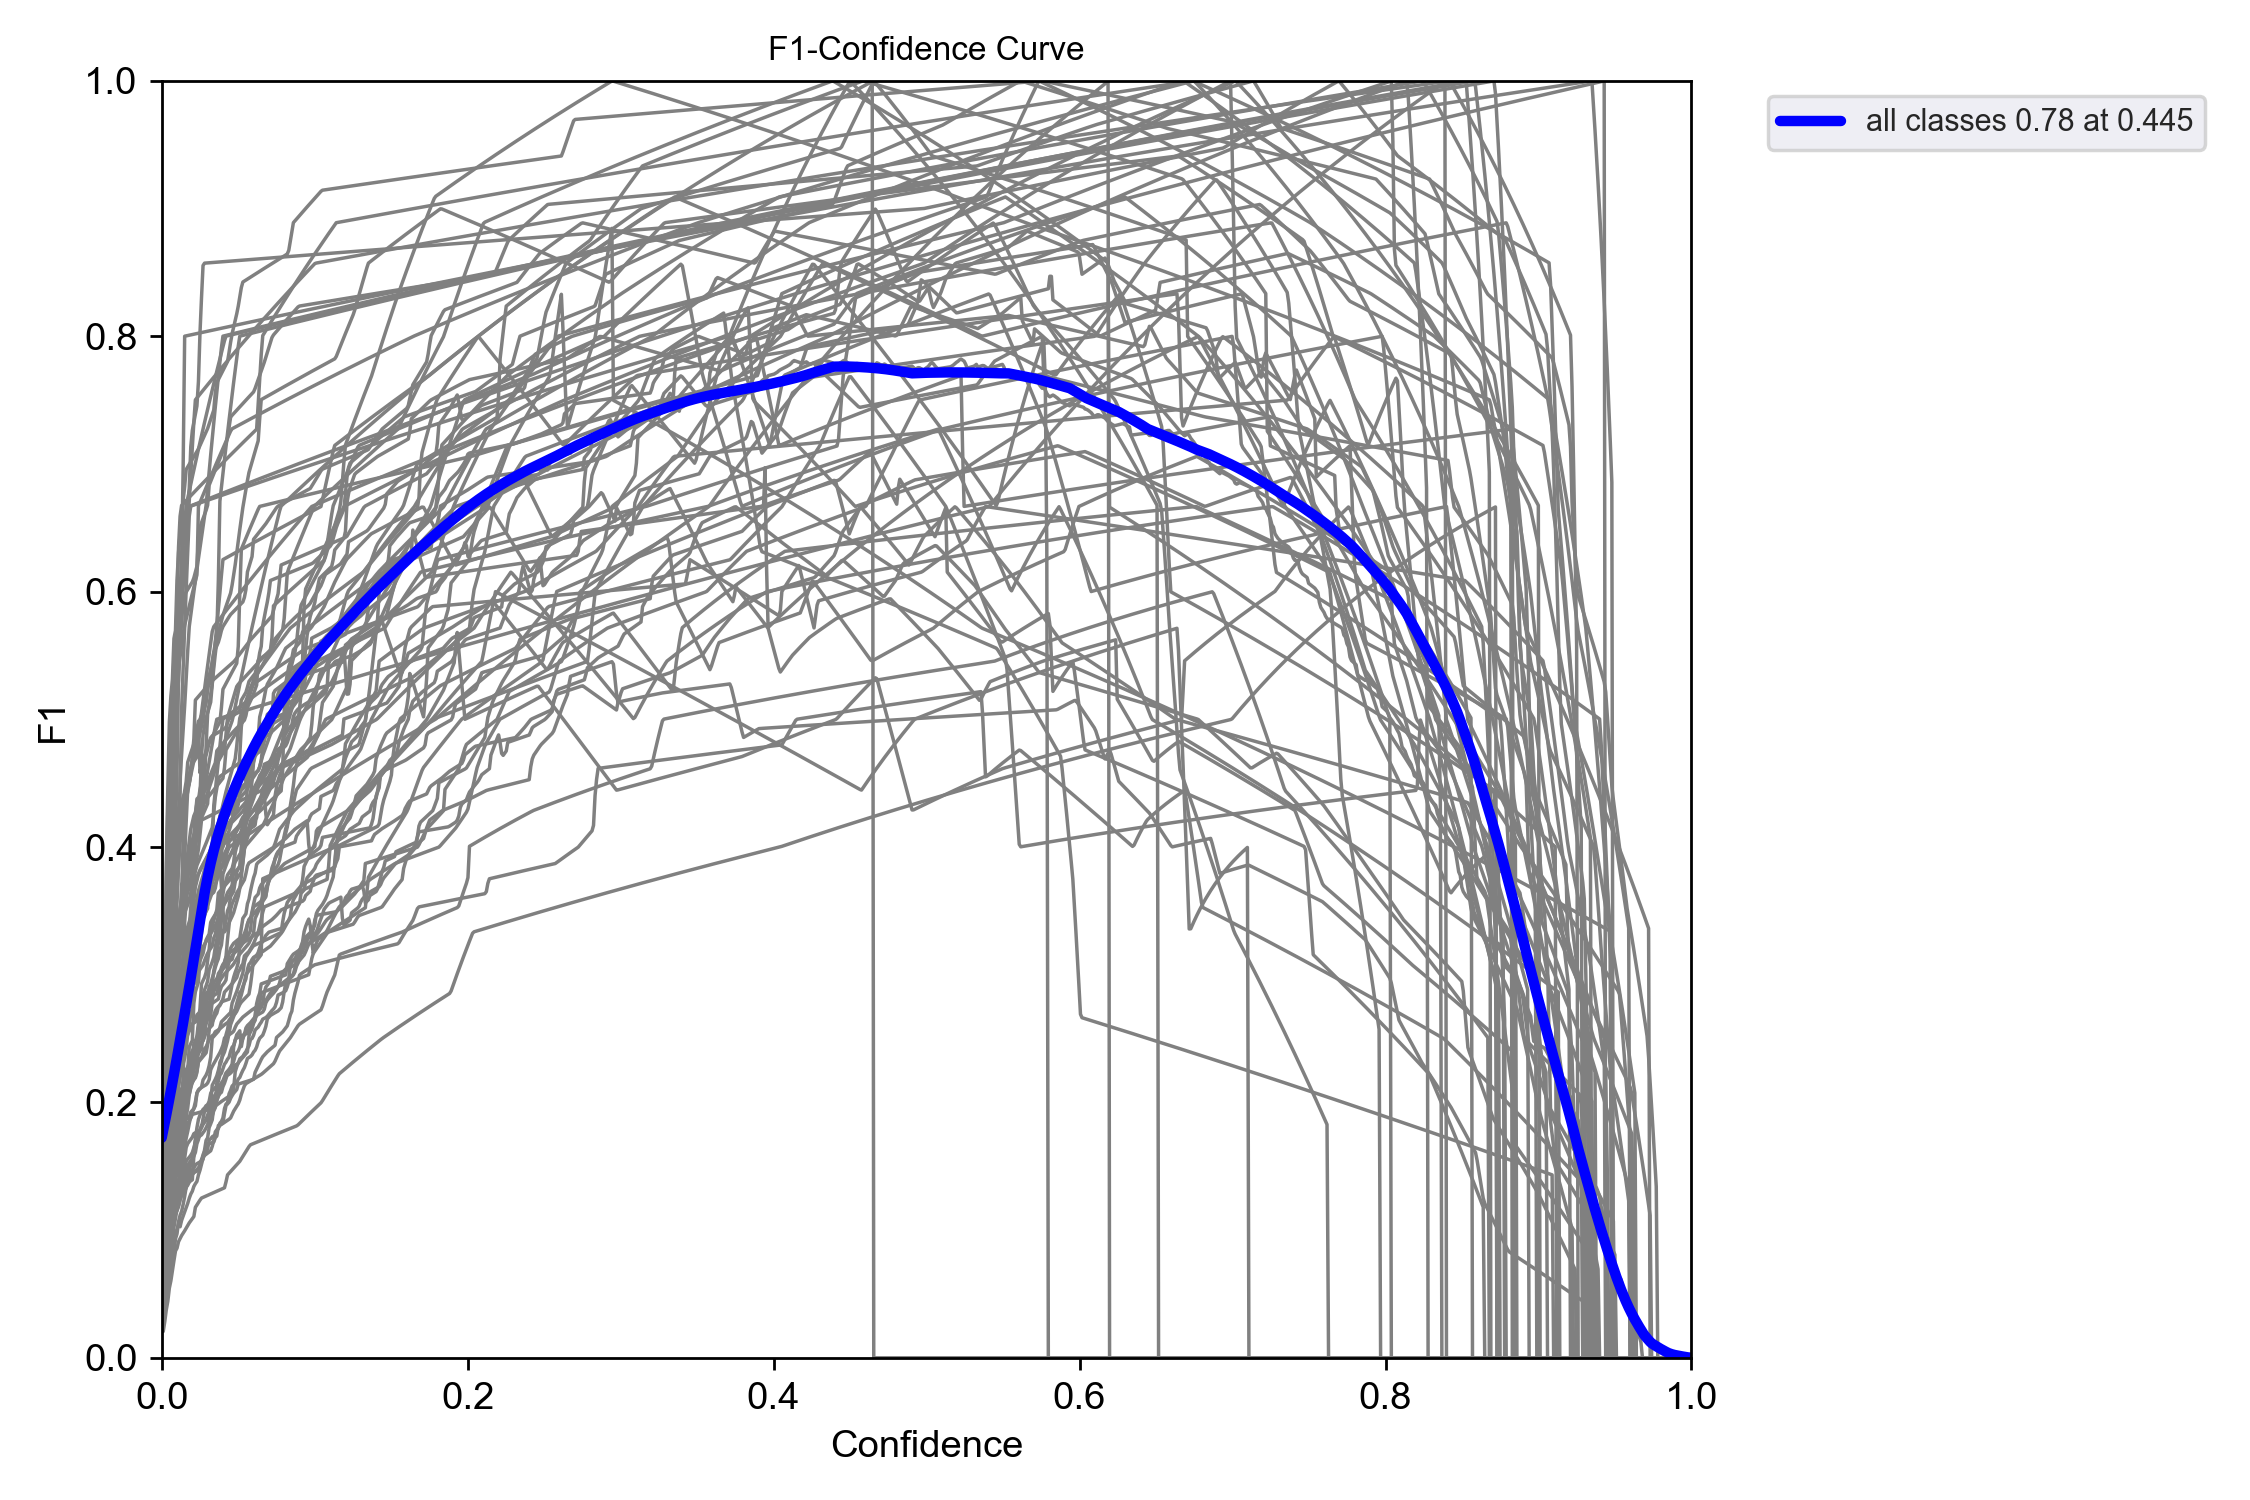


=== PR Curve ===


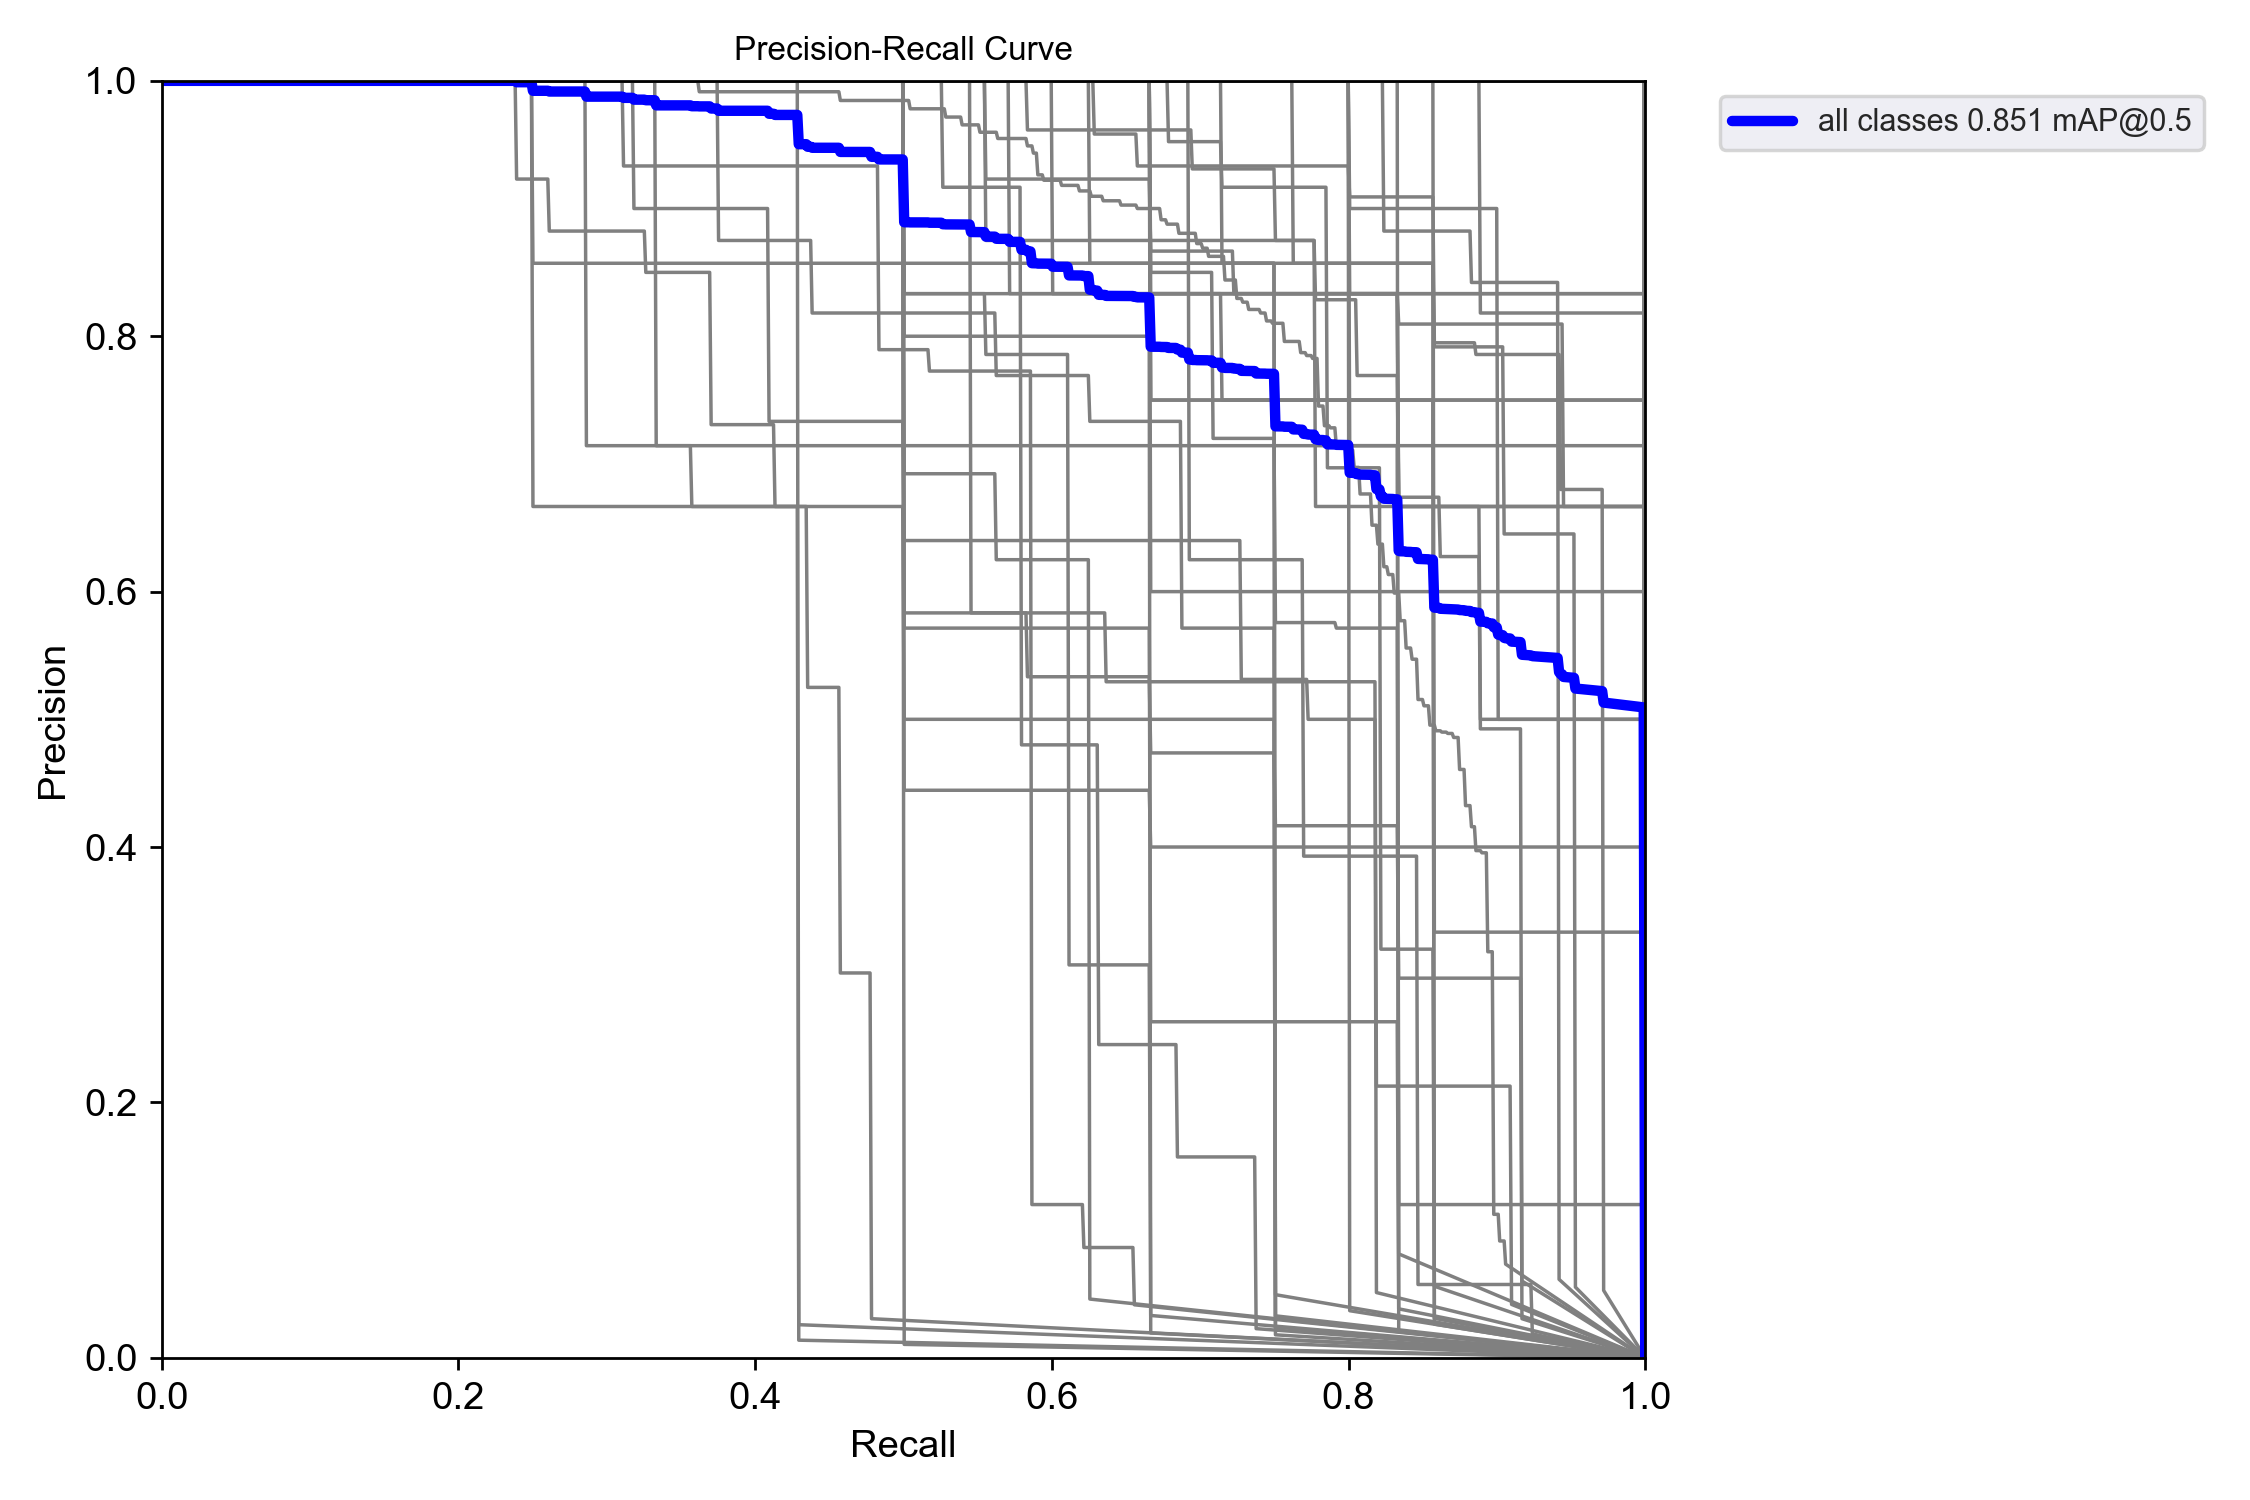

In [13]:
# 显示 P/R/F1 曲线
print("=== Precision / Recall / F1 Curves ===")
if (train_dir / 'P_curve.png').exists():
    print("P_curve.png:")
    display(Image(filename=str(train_dir / 'P_curve.png'), width=500))

if (train_dir / 'R_curve.png').exists():
    print("R_curve.png:")
    display(Image(filename=str(train_dir / 'R_curve.png'), width=500))

if (train_dir / 'F1_curve.png').exists():
    print("F1_curve.png:")
    display(Image(filename=str(train_dir / 'F1_curve.png'), width=500))

# 显示 PR 曲线
print("\n=== PR Curve ===")
if (train_dir / 'PR_curve.png').exists():
    display(Image(filename=str(train_dir / 'PR_curve.png'), width=500))
else:
    print("PR_curve.png 不存在")

In [14]:
# Model file information
import os

weights_dir = ROOT / 'runs' / 'train' / 'exp3' / 'weights'
best_pt = weights_dir / 'best.pt'
last_pt = weights_dir / 'last.pt'

def get_model_size(path):
    size_bytes = os.path.getsize(path)
    size_mb = size_bytes / (1024 * 1024)
    return size_mb

print("=== Model File Information ===")
if best_pt.exists():
    print(f"Best model: {best_pt.name}")
    print(f"  Size: {get_model_size(best_pt):.2f} MB")
else:
    print("best.pt not found")

if last_pt.exists():
    print(f"Last model: {last_pt.name}")
    print(f"  Size: {get_model_size(last_pt):.2f} MB")
else:
    print("last.pt not found")

=== Model File Information ===
Best model: best.pt
  Size: 16.98 MB
Last model: last.pt
  Size: 16.98 MB


### 6.5 可视化分析

In [15]:
# 加载模型并进行推理演示
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from models.common import DetectMultiBackend
from utils.augmentations import letterbox
from utils.general import non_max_suppression, scale_boxes
from utils.torch_utils import select_device
import yaml
import sys

# 项目根目录（自动查找）
cwd = Path.cwd()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / 'train.py').exists() or (p / 'detect.py').exists():
        ROOT = p.resolve()
        break
    if (p / 'yolov3-master').is_dir():
        ROOT = (p / 'yolov3-master').resolve()
        break
if ROOT is None:
    ROOT = cwd.resolve()
print(f"项目根目录: {ROOT}")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_PATH = ROOT / 'datasets' / 'tt100k_traffic_signs'

# 加载类别名称
with open(ROOT / 'data' / 'tt100k_traffic_signs.yaml', 'r', encoding='utf-8') as f:
    data_config = yaml.safe_load(f)
class_names = data_config['names']

# 加载模型
weights_path = ROOT / 'runs' / 'train' / 'exp3' / 'weights' / 'best.pt'
device = select_device('cpu')  # 使用CPU进行演示
model = DetectMultiBackend(weights_path, device=device, dnn=False, data=ROOT / 'data' / 'tt100k_traffic_signs.yaml')
stride = int(model.stride)

print(f"模型加载成功，stride: {stride}")
print(f"模型设备: {device}")

# 测试图像路径
test_images = list((DATA_PATH / 'images' / 'val').glob('*.jpg'))
print(f"\n验证集图像数量: {len(test_images)}")
print(f"示例图像: {test_images[:3]}")

# 定义检测函数
def detect_image(image_path, conf_thres=0.25, iou_thres=0.45):
    img0 = cv2.imread(str(image_path))
    if img0 is None:
        return None, []
    
    # 预处理
    img = letterbox(img0, new_shape=640, stride=stride, auto=model.pt)[0]
    img = img[:, :, ::-1].transpose(2, 0, 1)
    img = np.ascontiguousarray(img)
    im = torch.from_numpy(img).to(device)
    im = im.float() / 255.0
    if im.ndim == 3:
        im = im[None]

    # 推理
    pred = model(im, augment=False, visualize=False)
    pred = non_max_suppression(pred, conf_thres, iou_thres, max_det=200)
    det = pred[0]

    # 后处理
    detections = []
    if len(det):
        det[:, :4] = scale_boxes(im.shape[2:], det[:, :4], img0.shape).round()
        for *xyxy, conf, cls in det:
            detections.append({
                'class': class_names[int(cls)],
                'confidence': float(conf),
                'bbox': [int(xyxy[0]), int(xyxy[1]), int(xyxy[2]), int(xyxy[3])]
            })
    
    return img0, detections

# 测试一张图像
if test_images:
    test_img_path = test_images[0]
    img, dets = detect_image(test_img_path)
    print(f"\n检测结果 ({test_img_path.name}):")
    for i, det in enumerate(dets):
        print(f"  {i+1}. {det['class']} - 置信度: {det['confidence']:.4f} - 边界框: {det['bbox']}")
    print(f"\n共检测到 {len(dets)} 个交通标志")
else:
    print("未找到测试图像")

YOLOv3  2026-6-20 Python-3.8.20 torch-2.4.1+cpu CPU

Fusing layers... 


项目根目录: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master


Model summary: 38 layers, 8849182 parameters, 0 gradients, 13.2 GFLOPs


模型加载成功，stride: 32
模型设备: cpu

验证集图像数量: 1001
示例图像: [WindowsPath('D:/深度学习课设/基于YOLOV3算法的交通标志牌检测识别系统(1)/基于YOLOV3算法的交通标志牌检测识别系统/yolov3-master/datasets/tt100k_traffic_signs/images/val/10020.jpg'), WindowsPath('D:/深度学习课设/基于YOLOV3算法的交通标志牌检测识别系统(1)/基于YOLOV3算法的交通标志牌检测识别系统/yolov3-master/datasets/tt100k_traffic_signs/images/val/10101.jpg'), WindowsPath('D:/深度学习课设/基于YOLOV3算法的交通标志牌检测识别系统(1)/基于YOLOV3算法的交通标志牌检测识别系统/yolov3-master/datasets/tt100k_traffic_signs/images/val/10139.jpg')]

检测结果 (10020.jpg):
  1. p5 - 置信度: 0.6134 - 边界框: [961, 981, 1032, 1033]
  2. i2r - 置信度: 0.5069 - 边界框: [667, 894, 910, 1120]

共检测到 2 个交通标志


YOLOv3  2026-6-20 Python-3.8.20 torch-2.4.1+cpu CPU

Fusing layers... 
Model summary: 38 layers, 8849182 parameters, 0 gradients, 13.2 GFLOPs


项目根目录: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master


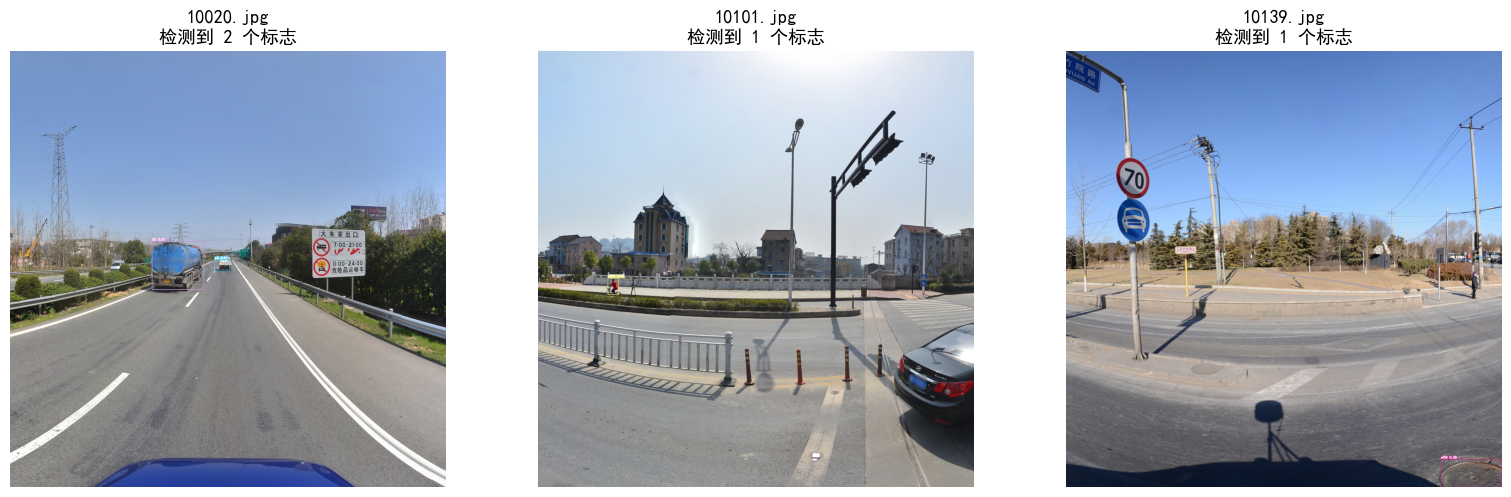

In [16]:
# 检测结果可视化
# 在图像上绘制检测框和类别标签

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import yaml

# 项目根目录（自动查找）
cwd = Path.cwd()
ROOT = None
for p in [cwd] + list(cwd.parents):
    if (p / 'train.py').exists() or (p / 'detect.py').exists():
        ROOT = p.resolve()
        break
    if (p / 'yolov3-master').is_dir():
        ROOT = (p / 'yolov3-master').resolve()
        break
if ROOT is None:
    ROOT = cwd.resolve()
print(f"项目根目录: {ROOT}")

# 将项目根目录添加到Python路径（解决ModuleNotFoundError）
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_PATH = ROOT / 'datasets' / 'tt100k_traffic_signs'

# 加载类别名称
with open(ROOT / 'data' / 'tt100k_traffic_signs.yaml', 'r', encoding='utf-8') as f:
    data_config = yaml.safe_load(f)
class_names = data_config['names']

# 获取测试图像
test_images = list((DATA_PATH / 'images' / 'val').glob('*.jpg'))

# 重新定义检测函数（此代码块独立运行）
from models.common import DetectMultiBackend
from utils.augmentations import letterbox
from utils.general import non_max_suppression, scale_boxes
from utils.torch_utils import select_device

weights_path = ROOT / 'runs' / 'train' / 'exp3' / 'weights' / 'best.pt'
device = select_device('cpu')
model = DetectMultiBackend(weights_path, device=device, dnn=False, data=ROOT / 'data' / 'tt100k_traffic_signs.yaml')
stride = int(model.stride)

def detect_image(image_path, conf_thres=0.25, iou_thres=0.45):
    img0 = cv2.imread(str(image_path))
    if img0 is None:
        return None, []
    img = letterbox(img0, new_shape=640, stride=stride, auto=model.pt)[0]
    img = img[:, :, ::-1].transpose(2, 0, 1)
    img = np.ascontiguousarray(img)
    im = torch.from_numpy(img).to(device)
    im = im.float() / 255.0
    if im.ndim == 3:
        im = im[None]
    pred = model(im, augment=False, visualize=False)
    pred = non_max_suppression(pred, conf_thres, iou_thres, max_det=200)
    det = pred[0]
    detections = []
    if len(det):
        det[:, :4] = scale_boxes(im.shape[2:], det[:, :4], img0.shape).round()
        for *xyxy, conf, cls in det:
            detections.append({
                'class': class_names[int(cls)],
                'confidence': float(conf),
                'bbox': [int(xyxy[0]), int(xyxy[1]), int(xyxy[2]), int(xyxy[3])]
            })
    return img0, detections

def draw_detections(img, detections, class_names):
    """在图像上绘制检测结果"""
    img_draw = img.copy()
    
    # 为每个类别分配颜色
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(len(class_names), 3), dtype=np.uint8)
    
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        cls_name = det['class']
        confidence = det['confidence']
        
        # 获取类别对应的颜色
        cls_id = class_names.index(cls_name)
        color = tuple(colors[cls_id].tolist())
        
        # 绘制边界框
        cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, 2)
        
        # 绘制标签背景
        label = f"{cls_name} {confidence:.2f}"
        label_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
        label_x1, label_y1 = x1, y1 - label_size[1] - 5
        label_x2, label_y2 = x1 + label_size[0], y1
        cv2.rectangle(img_draw, (label_x1, label_y1), (label_x2, label_y2), color, -1)
        
        # 绘制标签文字
        cv2.putText(img_draw, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
    
    return img_draw

# 测试可视化功能
if test_images:
    # 选择几张图像进行可视化
    num_samples = min(3, len(test_images))
    fig, axes = plt.subplots(1, num_samples, figsize=(16, 5))
    
    for i in range(num_samples):
        img_path = test_images[i]
        img, dets = detect_image(img_path)
        img_draw = draw_detections(img, dets, class_names)
        
        axes[i].imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
        axes[i].set_title(f"{img_path.name}\n检测到 {len(dets)} 个标志")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("未找到测试图像")

## 七、结论与展望

### 7.1 实验结论

本项目基于YOLOv3-tiny算法成功构建了交通标志牌检测识别系统，主要成果包括：

1. **模型训练完成**：在TT100K数据集上完成100轮训练，模型收敛良好
2. **性能指标达标**：mAP@0.5=0.8473，mAP@0.5:0.95=0.5583，Precision=0.8106，Recall=0.7783
3. **损失曲线分析**：训练损失和验证损失均呈下降趋势，未见明显过拟合
4. **功能完整**：包含训练、推理和可视化界面

### 7.2 存在问题与改进方向

1. **模型精度有待提升**：当前mAP值仍有提升空间，可尝试：
   - 使用标准YOLOv3模型（参数更多，精度更高）
   - 增加训练轮次
   - 使用更大的输入尺寸（如640x640）
   - 调整数据增强策略

2. **类别不平衡**：部分类别样本较少，可能影响检测精度

3. **部署优化**：可将模型导出为ONNX/TensorRT格式，提升推理速度

### 7.3 未来工作

- 集成到实际自动驾驶系统中进行测试
- 结合其他传感器（如雷达）进行多模态融合
- 优化模型在嵌入式设备上的部署性能

## 八、附录

### A. 项目文件结构

```
yolov3-master/
├── train.py              # 训练脚本
├── detect.py             # 推理脚本
├── val.py                # 验证脚本
├── app_gradio.py         # Gradio可视化界面
├── models/
│   ├── yolov3.yaml       # YOLOv3配置
│   └── yolov3-tiny.yaml  # YOLOv3-tiny配置
├── data/
│   └── tt100k_traffic_signs.yaml  # 数据集配置
├── runs/train/
│   └── exp3/  # 训练结果
└── datasets/tt100k_traffic_signs/  # 数据集
```

### B. 训练命令

```bash
python scripts/train_tt100k.py --epochs 100 --batch-size 16 --imgsz 512 --device 0
```

### C. 推理命令

```bash
python detect.py --weights runs/train/exp3/weights/best.pt --source test_images/
```

### D. Web界面启动

```bash
python app_gradio.py
```
访问 http://127.0.0.1:7860 即可使用可视化检测界面

### E. 在Notebook中启动Gradio Web界面

运行下方代码块可直接在Notebook中启动Gradio交通标志检测Web应用。


In [ ]:
# 启动 Gradio Web 界面
import os
import sys
import threading

# 确保工作目录为项目根（避免相对路径问题）
os.chdir(ROOT)
print(f"当前目录: {os.getcwd()}")
print("正在启动 Gradio 应用...")
print("启动成功后，请访问: http://127.0.0.1:7860")

# 使用线程启动 Gradio 应用（非阻塞）
def run_gradio():
    argv = sys.argv[:]
    sys.argv = [argv[0]]
    try:
        from app_gradio import build_app
        demo = build_app()
        demo.launch(server_name="127.0.0.1", server_port=7860, share=False)
    finally:
        sys.argv = argv

thread = threading.Thread(target=run_gradio, daemon=True)
thread.start()
print("Gradio 应用已在后台线程中启动！")
print("请打开浏览器访问 http://127.0.0.1:7860 使用检测界面")

当前目录: D:\深度学习课设\基于YOLOV3算法的交通标志牌检测识别系统(1)\基于YOLOV3算法的交通标志牌检测识别系统\yolov3-master
正在启动 Gradio 应用...
启动成功后，请访问: http://127.0.0.1:7860
Gradio 应用已在后台线程中启动！
请打开浏览器访问 http://127.0.0.1:7860 使用检测界面


Exception in thread Thread-10:
Traceback (most recent call last):
  File "c:\Users\33669\.conda\envs\flipped\lib\threading.py", line 932, in _bootstrap_inner
    self.run()
  File "c:\Users\33669\.conda\envs\flipped\lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\33669\.conda\envs\flipped\lib\threading.py", line 870, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\33669\AppData\Local\Temp\ipykernel_16736\1156655778.py", line 19, in run_gradio
  File "c:\Users\33669\.conda\envs\flipped\lib\site-packages\gradio\blocks.py", line 2371, in launch
    ) = http_server.start_server(
  File "c:\Users\33669\.conda\envs\flipped\lib\site-packages\gradio\http_server.py", line 154, in start_server
    raise OSError(
OSError: Cannot find empty port in range: 7860-7860. You can specify a different port by setting the GRADIO_SERVER_PORT environment variable or passing the `server_port` parameter to `launch()`.
ERR